# ML- Final Project - Machine Learning Fall 2024

- **Name:** `Mohammad Ali Olama`
- **Student ID:** `Your Student ID`

---

### Submission Deadline: **January 29, 2025**
#### Submit your assignment via Microsoft Teams.
#### File Naming Format: `ML_Project__LASTNAME_STUDENTID.ipynb`

---

### *Instructions for Completing the Problem Set:*

- **(Important Note) : Please do not submit a Colab link for your assignment answers. Instead, make sure to download your work as a `.ipynb` file and attach it directly to your submission. This is essential for proper grading and review.**

If you have any questions or need further assistance, feel free to reach out to me via Telegram:

* [Ali Zahedzadeh](https://t.me/scrpne)

Good luck ! 🚀

<hr>

In [ ]:
# IMPORTANT unistall and install sklearn 1.5.2

# !pip uninstall scikit-learn -y
# !pip install scikit-learn==1.5.2
import sklearn
sklearn.__version__


'1.5.2'

In [ ]:
!pip install emoji

In [ ]:
!pip install hazm

### **<font face="Courier New" color="blue" size="+3">Introduction</font>**



![score_cvd](https://s8.uupload.ir/files/robot_by_dall-e_2_eqjk.jpg)





Welcome to the final Machine Learning project! 🤩🎉 In this project, we aim to take you on an exciting journey into the world of Natural Language Processing (NLP), allowing you to test all the machine learning knowledge and skills you have acquired so far in one of the most popular application domains. In this domain, if we consider a machine learning model as the grumpy robot (!) in the image above, the goal will be to create a robot that can examine textual documents and generate responses to our requests based on its level of understanding of the texts.

In this project, you will work with various real-world datasets to tackle several exciting industrial problems. Additionally, a few lessons are included to familiarize you with some of the more specialized concepts needed for this project. For instance, the primary question that arises when working with textual data is: how do we feed such data into machine learning algorithms that understand only numbers? You will find the answer in the next lesson. Dive in! 😎



<hr>

### **<font face="Courier New" color="blue" size="+3">Text Embedding</font>**

In many problems, our dataset includes features in the form of textual documents. As you have heard multiple times in this course, machine learning algorithms only accept numerical inputs. So, how can we encode our available texts into numerical form to feed into the model? This is where the concept of `Text Embedding` comes into play. Using text embedding techniques, we can transform each textual document into a meaningful vector of real-valued numbers and then provide these vectors as input to our model.

In the following parts of this notebook, we will introduce a few basic text embedding methods commonly used in the field of Natural Language Processing, which will help us tackle the project. However, keep in mind that more advanced and powerful techniques also exist, capable of producing much more meaningful vectors. You will surely encounter these techniques in the future when you delve into the world of deep learning.



#### <font face="Verdana" color="green" size="+2">**Bag of Words (BoW)**

In this method, we take a very simple approach by considering only the occurrence of each word in a text corpus. In the **Bag of Words** method, the order of words in the text does not matter to us; what matters is which words appear in the text. To get familiar with this method, suppose our corpus consists of the two text documents below:


1.   So many books, so little time.
2.   A room without books is like a body without a soul.

First, we need to identify the unique words in our corpus and build what is called a Vocabulary. Assume that as part of preprocessing, we have removed punctuation marks and converted all characters to lowercase. Our vocabulary will look like this:

| **so** | **many** | **books** | **little** | **time** | **a** | **room** | **without** | **is** | **like** | **body** | **soul** |

Now, to embed each document, we can consider a vector with a size equal to the length of the vocabulary. For each word present in the text document, we place a 1 in the corresponding element of the vector. In the embedded vector, a 1 indicates that the corresponding word appears in the document, while a 0 indicates that the word does not appear. See the following example:

|       | so | many | books | little | time | a | room | without | is | like | body | soul |
|-------|----|------|-------|--------|------|---|------|---------|----|------|------|------|
| Text 1|  1 |    1 |     1 |      1 |    1 | 0 |    0 |       0 |  0 |    0 |    0 |    0 |
| Text 2|  0 |    0 |     1 |      0 |    0 | 1 |    1 |       1 |  1 |    1 |    1 |    1 |

This type of embedding is called binary embedding, as it only indicates the presence or absence of words. However, we can also use other methods:

**Count:** In this method, we use the number of times a word appears in the document.

**Frequency:** In this method, we calculate the frequency of the word by dividing the number of occurrences of the word by the total number of words in the document.

For example, if we use the count method for scoring in the earlier example, the result will look like this:

|       | so | many | books | little | time | a | room | without | is | like | body | soul |
|-------|----|------|-------|--------|------|---|------|---------|----|------|------|------|
| Text 1|  2 |    1 |     1 |      1 |    1 | 0 |    0 |       0 |  0 |    0 |    0 |    0 |
| Text 2|  0 |    0 |     1 |      0 |    0 | 3 |    1 |       2 |  1 |    1 |    1 |    1 |

Here, we considered only two documents as an example. In practice, your corpus will be much larger, and the number of unique words may reach thousands or even millions, resulting in very long embedding vectors. Moreover, for each vector generated, a large number of elements will have a value of 0. In such cases, it is necessary to use various techniques to reduce the size of the vocabulary. Some simple techniques for this include:

- Converting all characters to lowercase.
- Removing punctuation marks.
- Removing numbers.
- Removing stop words (words that are very frequent but do not carry much information, such as "a," "of," "the," etc.).
- Normalizing words.
- Stemming: Reducing words to their root forms (e.g., converting "playing" to "play").
- Thresholding word occurrences: Adding only those words to the vocabulary whose occurrences exceed a chosen threshold and discarding the rest.


To perform vectorization using this technique, we can use the **CountVectorizer** from the scikit-learn library as shown below:

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = ['so many books so little time', 'a room without books is like a body without a soul']
count_vect = CountVectorizer()
count_vect.fit(corpus)
final_counts = count_vect.transform(corpus)

print(count_vect.get_feature_names_out())
print(final_counts.toarray()[0])
print(final_counts.toarray()[1])

['body' 'books' 'is' 'like' 'little' 'many' 'room' 'so' 'soul' 'time'
 'without']
[0 1 0 0 1 1 0 2 0 1 0]
[1 1 1 1 0 0 1 0 1 0 2]


Important Arguments of **CountVectorizer**

| **Argument**      | **Description**                                                                                      |
|--------------------|------------------------------------------------------------------------------------------------------|
| `lowercase`       | If `True`, converts all characters to lowercase.                                                     |
| `preprocessor`    | Allows you to define a custom preprocessing function to apply to the text.                          |
| `tokenizer`       | Allows you to define a custom tokenization function to separate text into tokens.                   |
| `stop_words`      | If set to `english`, uses the default list of English stop words. Custom stop word lists can be used.|
| `max_df`          | Words with a document frequency higher than this value are ignored during vocabulary creation.       |
| `min_df`          | Words with a document frequency lower than this value are ignored during vocabulary creation.       |
| `max_features`    | If set to a number, keeps only the top `max_features` words based on frequency.                     |
| `binary`          | If `True`, uses binary scoring instead of counts or frequencies.                                    |



#### <font face="Verdana" color="green" size="+2">**N-Gram**



You might have heard of the term **N-gram**. Google offers a service called **Google Ngram Viewer**, which can find the frequency of your desired text sequences in printed sources and plot them as a chart. For example, it can generate a chart similar to the one below:


![score_cvd](https://s8.uupload.ir/files/google_n-gram_h8pz.png)

An **N-gram** is simply a sequence of **N words**. For example, given the text `I love New York`, the following N-grams can be generated:

| **1-gram (unigram)** | **2-gram (bigram)** | **3-gram (trigram)**   | **4-gram**           |
|-----------------------|---------------------|-------------------------|-----------------------|
| I                    | I love             | I love New             | I love New York       |
| love                 | love New           | love New York          |                       |
| New                  | New York           |                         |                       |
| York                 |                    |                         |                       |

**Using N-grams in Bag of Words**

In the previously introduced **Bag of Words** method, we created vectors based solely on individual words, equivalent to the **unigram** case. However, we can use the **N-gram** technique to build vectors based on, for example, word pairs (**bigram**). This approach incorporates some level of **context** in the text. For instance, considering the combination `New York` as a single unit makes more sense than treating `New` and `York` separately. Separating `New` could lead to entirely different meanings.

Additionally, if we exclusively use bigrams and omit unigrams, the length of the generated vector will also be smaller, which is a significant advantage.

To use N-grams in your code, you simply need to set the `ngram_range` argument in **CountVectorizer** to the desired N range. For example:
- If you want to include both **unigrams** and **bigrams**, set it to `(1,2)`.
- If you only need **bigrams**, set it to `(2,2)` as shown below:


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = ['so many books so little time', 'a room without books is like a body without a soul']
count_vect = CountVectorizer(ngram_range=(2,2))
count_vect.fit(corpus)
final_counts = count_vect.transform(corpus)

print(count_vect.get_feature_names_out())
print(final_counts.toarray()[0])
print(final_counts.toarray()[1])

['body without' 'books is' 'books so' 'is like' 'like body' 'little time'
 'many books' 'room without' 'so little' 'so many' 'without books'
 'without soul']
[0 0 1 0 0 1 1 0 1 1 0 0]
[1 1 0 1 1 0 0 1 0 0 1 1]


#### <font face="Verdana" color="green" size="+2">**TF-IDF**



**Addressing High-Frequency Words**

One issue with scoring based on **frequency** or **counting** is that common words like "the" may appear frequently in a document and receive a high score, even though such words do not provide much informational content for the model.

To address this issue, we can rescale the frequency of words based on how often they appear across all documents. This technique is called **TF-IDF**, which consists of the following two components:

1. **Term Frequency (TF):**  
   A score based on the frequency of the word in the current document. It is calculated by dividing the number of occurrences of the word in the document by the total number of words in that document.  
   $$
   \text{TF} = \frac{\text{Count of word in document}}{\text{Total words in document}}
   $$

2. **Inverse Document Frequency (IDF):**  
   A score based on how rare the word is across all documents. It is calculated by dividing the total number of documents by the number of documents containing the word and then taking the logarithm.

   $$
   \text{IDF} = \log \left( \frac{\text{Total documents}}{\text{Number of documents containing the word}} \right)
   $$

The final **TF-IDF score** is obtained by multiplying the TF and IDF components:

$$
\text{TF-IDF} = \text{TF} \times \text{IDF}
$$

**Example Calculation:**

- Suppose a document contains 1000 words, and the word "a" appears 50 times.  
  $$
  \text{TF} = \frac{50}{1000} = 0.05
  $$
- If there are 3000 documents in total and the word "a" appears in 100 of them:  
  $$
  \text{IDF} = \log \left( \frac{3000}{100} \right) = 1.47
  $$
- The final TF-IDF score:  
  $$
  \text{TF-IDF} = 0.05 \times 1.47 = 0.073
  $$

**Vectorization Using TF-IDF**

To perform vectorization using TF-IDF, you can directly use **TfidfVectorizer** from scikit-learn:


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = ['so many books so little time', 'a room without books is like a body without a soul']
tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(corpus)
final_counts = tfidf_vect.transform(corpus)

print(tfidf_vect.get_feature_names_out())
print(final_counts.toarray()[0])
print(final_counts.toarray()[1])

['body' 'books' 'is' 'like' 'little' 'many' 'room' 'so' 'soul' 'time'
 'without']
[0.         0.25969799 0.         0.         0.36499647 0.36499647
 0.         0.72999294 0.         0.36499647 0.        ]
[0.32433627 0.23076793 0.32433627 0.32433627 0.         0.
 0.32433627 0.         0.32433627 0.         0.64867255]


The second approach to generating TF-IDF vectors is by using the vectors created by **CountVectorizer** and transforming them into TF-IDF vectors using **TfidfTransformer**. To streamline the process, we can combine these steps into a single pipeline.



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer

pipe = Pipeline([('count', CountVectorizer()),
                 ('tfidf', TfidfTransformer())])

pipe.fit(corpus)
final_counts = pipe.transform(corpus)

print(pipe.get_feature_names_out())
print(final_counts.toarray()[0])
print(final_counts.toarray()[1])

['body' 'books' 'is' 'like' 'little' 'many' 'room' 'so' 'soul' 'time'
 'without']
[0.         0.25969799 0.         0.         0.36499647 0.36499647
 0.         0.72999294 0.         0.36499647 0.        ]
[0.32433627 0.23076793 0.32433627 0.32433627 0.         0.
 0.32433627 0.         0.32433627 0.         0.64867255]


### **<font face="Courier New" color="blue" size="+3">Question 1: Gender Detection (10 points)</font>**

#### <font face="Verdana" color="green" size="+2">**Introduction and Problem Statement**


Social media platforms serve multiple purposes in today's world. While their primary use is for entertainment and leisure, they can also be valuable tools for identifying behavioral patterns. For example, by analyzing social media user comments, businesses can identify areas for improvement in their operations.

Gender is one of the influential parameters in user behavior. When faced with a particular topic or situation, women generally tend to react in one way while men may react differently.

In this exercise, we will use data from Twitter and Instagram users to predict their gender.

#### <font face="Verdana" color="green" size="+2">**Required Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Start by importing the necessary libraries:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score,precision_score
from sklearn.ensemble import RandomForestClassifier

#### <font face="Verdana" color="green" size="+2">**Dataset Description**

The dataset contains 8000 rows and 10 columns. The following table provides detailed information about the data:

| Column | Description |
|:------:|:------------|
|gender|Gender (target column)|
|age|User's age range|
|fullname|Name shown in social media profile|
|username|Username|
|biography|User's social media biography|
|follower_count|Number of followers|
|following_count|Number of accounts the user follows|
|is_business|Whether the account is a business account|
|is_verified|Whether the account is verified|
|is_private|Whether the account is private|

Note: The `age` column is not a continuous variable; instead, it represents age categories as shown below:

| Actual Age Range | Mapped Value |
|:---------------:|:------------:|
|1|Under 18 years|
|2|19 to 29 years|
|3|30 to 40 years|
|4|Over 40 years|

#### <font face="Verdana" color="green" size="+2">**Loading the Dataset**

First, you need to load the dataset file. The data samples are stored in `gender_detection.csv`.



In [ ]:
gender_detection = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/Project/data/gender_detection.csv')
gender_detection.head()

,gender,age,fullname,username,biography,follower_count,following_count,is_business,is_verified,is_private
0,man,2,Farshid,mr_gh_farshid,دردا ک در این بادیه بسیار دویدیم...\nGlory man...,1604.0,1407.0,0.0,0.0,0.0
1,woman,2,zahr@72,zahra.roozbahani72,"خواهی که زکوچ در امان برگردی\nباید که به جان ,...",67.0,501.0,0.0,0.0,0.0
2,woman,2,ms farahnaz♥,___lady.farahnazi.__,"Having you, is all I wish for \nداشتنت، تمامِ...",0.0,0.0,0.0,0.0,0.0
3,woman,1,Lena.mommy farzan,mommy.lena3361,دردونه من لنا کوچولو,0.0,0.0,0.0,0.0,0.0
4,woman,2,Narsis Asadollahi,_l.aurora.l_,I am an animation student\n🎧🎼🎨⚓️🤍 \n@general.m...,200.0,328.0,0.0,0.0,0.0


#### <font face="Verdana" color="green" size="+2">**Preprocessing and Feature Engineering (7 points)**

In this part, you can use any **preprocessing/feature** engineering
techniques that you learned in previous chapters (and in your machine learning course).







#### EDA
first let's have a look at our dataset:

In [ ]:
gender_detection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           8000 non-null   object 
 1   age              8000 non-null   int64  
 2   fullname         8000 non-null   object 
 3   username         8000 non-null   object 
 4   biography        8000 non-null   object 
 5   follower_count   8000 non-null   float64
 6   following_count  8000 non-null   float64
 7   is_business      7997 non-null   float64
 8   is_verified      8000 non-null   float64
 9   is_private       8000 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 625.1+ KB


In [ ]:
gender_detection.describe()

,age,follower_count,following_count,is_business,is_verified,is_private
count,8000.000000,8000.000000,8000.00000,7997.000000,8000.000000,8000.000000
mean,2.659875,2745.200250,712.20650,0.103289,0.000125,0.000125
std,0.724228,20156.322638,1465.37601,0.304355,0.011180,0.011180
min,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,3.000000,124.000000,133.00000,0.000000,0.000000,0.000000
75%,3.000000,917.250000,681.00000,0.000000,0.000000,0.000000
max,4.000000,845016.000000,7509.00000,1.000000,1.000000,1.000000


#### Count NA

In [ ]:
gender_detection.isna().sum()

,0
gender,0
age,0
fullname,0
username,0
biography,0
follower_count,0
following_count,0
is_business,3
is_verified,0
is_private,0


only 3 samples have null 'is_business' field. We can assume that those accounts are not business accounts, or just simply ignore and drop them. let's assume they are non-business.

In [ ]:
gender_detection['is_business'] = gender_detection['is_business'].fillna(0)
gender_detection.isna().sum()

,0
gender,0
age,0
fullname,0
username,0
biography,0
follower_count,0
following_count,0
is_business,0
is_verified,0
is_private,0


Our dataset has several categorical fields. let's have a look at each:

In [ ]:
# Value Counts for categorical Columns
def show_count_values(args):
    for col in args:
        print(gender_detection[col].value_counts())
        print("++++++++++++++++++++++++++++++++++")

show_count_values(['gender','age','is_business','is_verified','is_private'])

gender
man      4000
woman    4000
Name: count, dtype: int64
++++++++++++++++++++++++++++++++++
age
2    3429
3    3371
4    1036
1     164
Name: count, dtype: int64
++++++++++++++++++++++++++++++++++
is_business
0.0    7174
1.0     826
Name: count, dtype: int64
++++++++++++++++++++++++++++++++++
is_verified
0.0    7999
1.0       1
Name: count, dtype: int64
++++++++++++++++++++++++++++++++++
is_private
0.0    7999
1.0       1
Name: count, dtype: int64
++++++++++++++++++++++++++++++++++


We can plot those columns to have a better visualization:

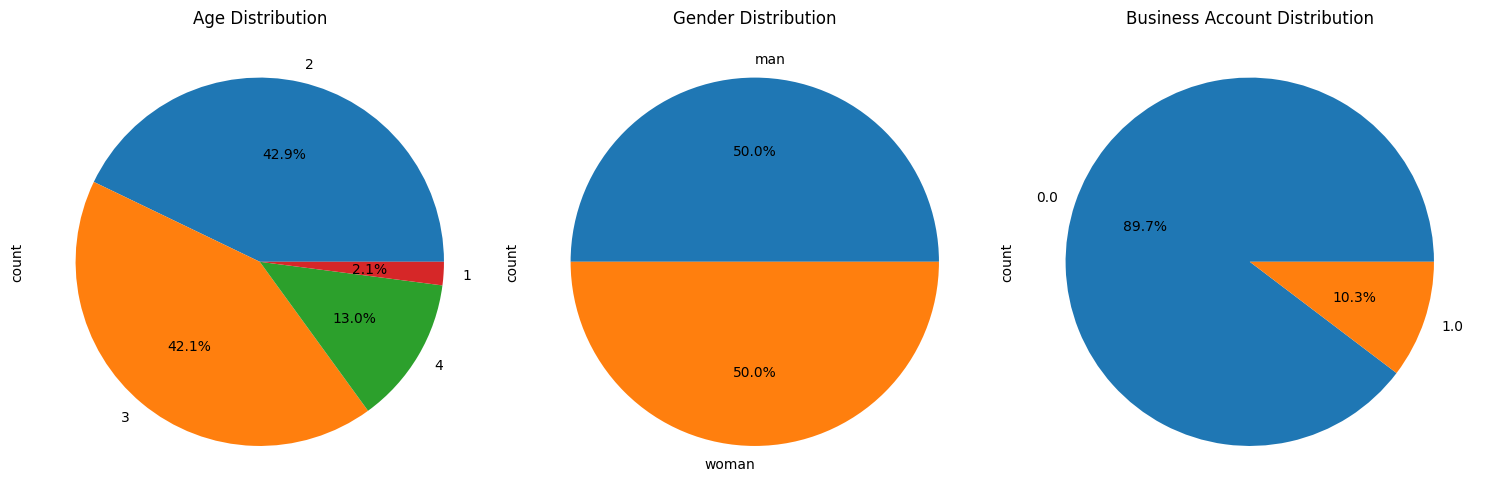

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age Distribution
gender_detection['age'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], title='Age Distribution')

# Gender Distribution
gender_detection['gender'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], title='Gender Distribution')

# Business Account Distribution
gender_detection['is_business'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[2], title='Business Account Distribution')

plt.tight_layout()
plt.show()


  Also we have only one person who is verified, and one person whose account is private. These makes our dataset very imbalanced according to these features. So it's better to just discard them:


In [ ]:
gender_detection = gender_detection[gender_detection['is_verified'] == 0]
gender_detection = gender_detection[gender_detection['is_private'] == 0]


#### Preprocessing

first we defind some utility functions to help us clean the data:


In [ ]:
# remove duplicate rows
def remove_duplicates(df):
    df.drop_duplicates(inplace=True)
    return df

# remove some columns
def remove_junk_cols(df, cols):
    for c in cols:
      print(c)
      df.drop(c, axis=1, inplace=True)
    return df

# categorical encoding
def handling_cat_cols(df, cols) :
    for c in cols:
      one_hot_encoded_df = pd.get_dummies(df[c], prefix=c)
      df = df.join(one_hot_encoded_df)
      df.drop(c, axis=1, inplace=True)
    return df

# handle missing values: simply drop missing rows
def handle_missing_values(df):
  # drop na
  df.dropna(inplace=True)
  return df

# normalize numerical columns using scaler
def normalize(df, cols, scaler):
    df[cols] = scaler.fit_transform(df[cols])
    return df

# clean text
def clean_text(text):
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'&amp;', 'and', text)
    text = re.sub(r'@', 'a', text)
    text = re.sub(r'[^a-zA-Z\s.]', '', text) # \s: contains a white space character. a-zA-Z: any character alphabetically between a and z, lower case OR upper case
    text = re.sub(r'\n', ' ', text)
    return text

# clean an input string given a regex and its replacement
def clean_text_with_regex(text , reg , to):
    text = re.sub(reg, to, text)
    return text

def count_words(text):
    return len(text.split())



Now we will clean the dataset, and add new features. The following features are added:
* biography length
* number of emojies used in biography

In [ ]:
from sklearn.preprocessing import LabelEncoder

# start cleaning dataset
df = remove_duplicates(gender_detection)
df = handle_missing_values(df)

In [ ]:
# label encode gender
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [ ]:
# Apply clean_text function to 'fullname' and 'username' columns
df['fullname'] = df['fullname'].apply(clean_text)
df['username'] = df['username'].apply(clean_text)

In [ ]:
# remove \n in biography
df['biography'] = df['biography'].apply(lambda x: clean_text_with_regex(x, r'\n', ''))

# count biography length as a new feature
df['bio_word_count'] = df['biography'].apply(count_words)

In [ ]:
# add new feature to show number of emoji
import emoji
from emoji import emoji_count

def count_emojis(text):
    return emoji_count(text)

df['emoji_count'] = df['biography'].apply(count_emojis)

In [ ]:
def count_hashtags(text):
  return text.count('#')

df['hashtag_count'] = df['biography'].apply(count_hashtags)


In [ ]:
df.head()

,gender,age,fullname,username,biography,follower_count,following_count,is_business,is_verified,is_private,bio_word_count,emoji_count,hashtag_count
0,0,2,Farshid,mrghfarshid,دردا ک در این بادیه بسیار دویدیم...Glory man u...,1604.0,1407.0,0.0,0.0,0.0,11,3,1
1,1,2,zahra,zahra.roozbahani,"خواهی که زکوچ در امان برگردیباید که به جان , ز...",67.0,501.0,0.0,0.0,0.0,13,0,0
2,1,2,ms farahnaz,lady.farahnazi.,"Having you, is all I wish for داشتنت، تمامِ آ...",0.0,0.0,0.0,0.0,0.0,16,8,0
3,1,1,Lena.mommy farzan,mommy.lena,دردونه من لنا کوچولو,0.0,0.0,0.0,0.0,0.0,4,0,0
4,1,2,Narsis Asadollahi,l.aurora.l,I am an animation student🎧🎼🎨⚓️🤍 @general.motion,200.0,328.0,0.0,0.0,0.0,6,5,0


#### train test split
since we have a balance dataset, a simply train-test split will work. we don't need and resampling(oversampling or undersampling) or stratify sampling.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('gender', axis=1)
y = df['gender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Another feature will be added. I decided to join fullname, username and biography of each person, then applly TF-IDF to extract a feature vector for each person. Then I will use this feature vector as a basis of training a supplimentry decision making algorithm. I select XGBoost for this task and predict the gender of each sample using only the vectorized features I have extracted above. Then this new feature(base predicted target) is added to the original dataset and then a main classifier will train on the original dataset.

In [ ]:
# convert text columns to vector
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

# the union of these three columns: fullname + username + biography
tfidf.fit(X_train['fullname'] + ' ' + X_train['username'] + ' ' + X_train['biography'])

# don't train on test data. just transform what we learn on it.
encoded_text_train = tfidf.transform(X_train['fullname'] + ' ' + X_train['username'] + ' ' + X_train['biography'])
encoded_text_test = tfidf.transform(X_test['fullname'] + ' ' + X_test['username'] + ' ' + X_test['biography'])

In [ ]:
import xgboost as xgb

# Create and train the XGBoost model
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
model.fit(encoded_text_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
gender_by_text_train = model.predict(encoded_text_train)
gender_by_text_test = model.predict(encoded_text_test)

X_train['gender_by_text'] = gender_by_text_train
X_test['gender_by_text'] = gender_by_text_test

print(f1_score(y_train, gender_by_text_train))

0.844906444906445


In [ ]:
X_train.drop(['fullname', 'username', 'biography'], axis=1, inplace=True)
X_test.drop(['fullname', 'username', 'biography'], axis=1, inplace=True)

In [ ]:
X_train.head()

,age,follower_count,following_count,is_business,is_verified,is_private,bio_word_count,emoji_count,hashtag_count,gender_by_text
5724,4,2240.0,285.0,1.0,0.0,0.0,15,12,0,0
2337,2,877.0,94.0,0.0,0.0,0.0,3,2,0,1
1578,2,0.0,0.0,0.0,0.0,0.0,11,7,0,1
6526,2,0.0,0.0,0.0,0.0,0.0,2,5,1,1
7621,2,73.0,456.0,0.0,0.0,0.0,8,2,0,1


#### <font face="Verdana" color="green" size="+2">**Modeling (2 points)**

Now that you have cleaned the data and potentially added or removed features, it's time to train a model that can predict the target variable for this problem.

I decided to use XGBoost again for this task. But this time, I will use gridSearch to tune hyperparameters of my model:

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.3, 0.1, 0.2],
}

# Create an XGBoost classifier
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1 , verbose=1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best score: 0.8542268113526221


#### <font face="Verdana" color="green" size="+2">**Evaluation Metric (1 point)**

The metric we have chosen to evaluate the model's performance is the `f1_score`.



**Note:** To achieve full marks, your solution needs to achieve a minimum score of `75%` according to the specified metric.

In [ ]:
# Evaluate the best model on the test data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f1_score(y_test,y_pred))


0.8233295583238958


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.73      0.78       769
           1       0.78      0.87      0.82       831

    accuracy                           0.81      1600
   macro avg       0.81      0.80      0.80      1600
weighted avg       0.81      0.81      0.80      1600



### **<font face="Courier New" color="blue" size="+3">Question 2: Topic Modeling (20 points)</font>**

#### <font face="Verdana" color="green" size="+2">**Introduction and Problem Statement**



In this part, we'll be working with real Persian web data. The goal is to build a machine learning model that can predict the topic category of a document based on various text features from a link, such as title, description, full text content, and more. For example, if we have a news site link with the title "کیهان کلهر جایزه مرد سال موسیقی جهان را دریافت کرد", our model should predict that this content belongs to the "موسیقی" category. While this example only uses the title feature, we can also utilize the description or text content to improve our predictions.

> **Note:** To use the algorithms introduced in this course for working with textual data, you need to be familiar with at least one embedding method to convert each text into a numerical feature vector.

#### <font face="Verdana" color="green" size="+2">**Required Libraries**

Start by importing the necessary libraries:

In [ ]:
import numpy as np
import pandas as pd
from hazm import *
import string

#### <font face="Verdana" color="green" size="+2">**Dataset Description**

Each sample in this dataset comes with features described in the table below. The `category` column is the target variable that indicates the content's topic.

| Column | Description |
|:------:|:------------|
|`category`| Topic (target variable) |
|`description`| Description |
|`text_content`| Text content |
|`title`| Title |
|`h1`| Page's `h1` tag content |
|`h2`| Page's `h2` tag content |
|`url`| Link address |
|`domain`| Website domain |
|`id`| Link ID |

#### <font face="Verdana" color="green" size="+2">**Loading the Dataset**

First, you need to load the dataset files. The data samples are stored in `topic_modeling.csv`.


In [ ]:
with open('/content/drive/MyDrive/TEIAS/ML/Project/data/topic_modeling.csv', 'r', encoding='utf-8', errors='replace') as f:
    topic_modeling = pd.read_csv(f)
topic_modeling.head()

,category,description,text_content,title,h1,h2,url,domain,id
0,کتاب و ادبیات,"از شوبنده ها: جستجو معنی ""از شوبنده ها"" در فره...",معنی از شوبنده ها | جدول یاب از شوبنده ها 381,معنی از شوبنده ها | جدول یاب,معنی از شوبنده ها,از شوبنده ها در معادل ابجد,jadvalyab.ir/search?q=%D8%A7%D8%B2+%D8%B4%D9%8...,jadvalyab.ir,158
1,تجارت و اقتصاد,بیت‌کوین کش یک ارز مجازی مشهور است و بیت‌کوین ...,عکس بیت‌کوین کش برای پروفایل عکس و والپیپرهای ...,عکس بیت‌کوین کش برای پروفایل,عکس بیت‌کوین کش برای پروفایل,عکس بیت کوین با کیفیت 4K عکس ارزهای دیجیتال عک...,jowhareh.com/photo/%D8%B9%DA%A9%D8%B3-%D8%A8%D...,jowhareh.com,3268
2,سلامت,نوبت دهی دکتر مهناز عابدینی متخصص رادیولوژی و ...,دکتر مهناز عابدینی متخصص رادیولوژی و سونوگرافی...,دکتر مهناز عابدینی متخصص رادیولوژی و سونوگرافی...,دکتر مهناز عابدینی,آدرس و تلفن دکتر مهناز عابدینی نظرات و تجربیات...,doctor-yab.ir/Search/14773/%D8%AF%DA%A9%D8%AA%...,doctor-yab.ir,175
3,تکنولوژی و کامپبوتر,نرم افزار Geph برای اندروید یک پلت‌فرم چندسکوی...,دانلود تحریم‌گذر Geph برای اندروید خانه/اندروی...,دانلود تحریم‌گذر Geph برای اندروید,دانلود تحریم‌گذر Geph برای اندروید,دانلود نرم افزار Geph,palexe.site/dl/geph-android/,palexe.site,3402
4,تکنولوژی و کامپبوتر,سری جدید تلویزیون‌های هوشمند سامسونگ که با نام...,ترفندهای پرکاربرد تلویزیون‌‌های هوشمند سامسونگ...,ترفندهای پرکاربرد تلویزیون‌‌های هوشمند سامسونگ...,ترفندهای پرکاربرد تلویزیون‌‌های هوشمند سامسونگ,راه‌اندازی تلویزیون همگام‌سازی کنترل اتصال به ...,rokhdadeghtesadi.ir/43874/,rokhdadeghtesadi.ir,3811


#### <font face="Verdana" color="green" size="+2">**Preprocessing and Feature Engineering (15 points)**

When working with textual data, preprocessing using NLP techniques is one of the most influential stages in model learning and final performance.

In this section, you can write a function that takes a `string`, applies your desired text modifications, and returns the result as a `string`. Analyzing and examining the frequency of words in the dataset can also help you with better preprocessing. (you can use [this](https://github.com/webilix/persian-preprocess) repository)


#### EDA

In [ ]:
topic_modeling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4789 entries, 0 to 4788
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   category      4789 non-null   object
 1   description   4743 non-null   object
 2   text_content  4789 non-null   object
 3   title         4789 non-null   object
 4   h1            4431 non-null   object
 5   h2            3350 non-null   object
 6   url           4789 non-null   object
 7   domain        4784 non-null   object
 8   id            4789 non-null   int64 
dtypes: int64(1), object(8)
memory usage: 336.9+ KB


In [ ]:
# Count NaN values in each column
topic_modeling.isna().sum()

,0
category,0
description,46
text_content,0
title,0
h1,358
h2,1439
url,0
domain,5
id,0


So we have a lot of Nan. But don't worry since I've decided to use only 'title' and 'text_content'. So let's create X and y datasets:

In [ ]:
X = topic_modeling[['title', 'text_content']]
y = topic_modeling['category']


Let's have a llok at the distribution of our target variables:

In [ ]:
y.value_counts()

,count
category,
سلامت,614
ورزش,514
حقوق و دولت و سیاست,486
هنر و سرگرمی,410
موسیقی,314
تکنولوژی و کامپبوتر,287
تجارت و اقتصاد,283
فیلم و سینما,239
خودرو,237


In [ ]:
import plotly.express as px
fig = px.histogram(y, x="category", title='Histogram different categories (Hover to see more details)')
fig.show()

When using embedding with the `scikit-learn` library, since the tokenizer used in this library might not be suitable for the Persian language, it's better to use tokenizers specific to this language. Simply write a function that takes a `string` and separates its tokens using your preferred library (like `word_tokenize` in the [HAZM](https://github.com/roshan-research/hazm) library). The function's output will be a list of tokens.

In [ ]:
def tokenizer(text):
    return word_tokenize(text)

In [ ]:
import re
from hazm import *
import hazm

def remove_punc(text):
    # Combine all unwanted characters into a single regex pattern
    pattern = r'[!"#$%&()*+,-./:;«»<=>?@[\]^_`{|}~1234567890۱۲۳۴۵۶۷۸۹۰،؛a-zA-Z]'

    # Replace all matching characters with a space
    cleaned_text = re.sub(pattern, ' ', text)
    cleaned_text = cleaned_text.replace("\n" , "").replace("\u200c" , " ")

    # Remove extra spaces (if any) and return the cleaned text
    return ' '.join(cleaned_text.split())

def remove_stopwords(text):
  stopwords = stopwords_list()
  text=text.replace("های", "").replace("ها" , "").replace("میشود", " ")
  text = text.split()
  result = [word for word in text if not word in stopwords]
  return ' '.join(result)

xxxx = 0
def preprocessor(text):
    text=remove_punc(text)
    text=remove_stopwords(text)
    return text

In [ ]:
# Apply remove_punc to each row of X['title'] and X['text_contentX'] manually
for index, row in X.iterrows():
    cleaned_title = preprocessor(row['title'])
    cleaned_body = preprocessor(row['text_content'])
    X.loc[index, 'titleX'] = cleaned_title
    X.loc[index, 'text_contentX'] = cleaned_body

<ipython-input-58-8510177b598b>:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-58-8510177b598b>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
X.head()

,title,text_content,titleX,text_contentX
0,معنی از شوبنده ها | جدول یاب,معنی از شوبنده ها | جدول یاب از شوبنده ها 381,معنی شوبنده جدول یاب,معنی شوبنده جدول یاب شوبنده
1,عکس بیت‌کوین کش برای پروفایل,عکس بیت‌کوین کش برای پروفایل عکس و والپیپرهای ...,عکس بیت کوین کش پروفایل,عکس بیت کوین کش پروفایل عکس والپیپر ارز دیجیتا...
2,دکتر مهناز عابدینی متخصص رادیولوژی و سونوگرافی...,دکتر مهناز عابدینی متخصص رادیولوژی و سونوگرافی...,دکتر مهناز عابدینی متخصص رادیولوژی سونوگرافی ب...,دکتر مهناز عابدینی متخصص رادیولوژی سونوگرافی ب...
3,دانلود تحریم‌گذر Geph برای اندروید,دانلود تحریم‌گذر Geph برای اندروید خانه/اندروی...,دانلود تحریم گذر اندروید,دانلود تحریم گذر اندروید خانه اندروید دانلود ت...
4,ترفندهای پرکاربرد تلویزیون‌‌های هوشمند سامسونگ...,ترفندهای پرکاربرد تلویزیون‌‌های هوشمند سامسونگ...,ترفند پرکاربرد تلویزیون هوشمند سامسونگ رخداد ا...,ترفند پرکاربرد تلویزیون هوشمند سامسونگ رخداد ا...


In [ ]:
import pandas as pd

# Create a new DataFrame with the combined data
combined_data = pd.DataFrame(X)
combined_data['gender'] = y
combined_data.head()


,title,text_content,titleX,text_contentX,gender
0,معنی از شوبنده ها | جدول یاب,معنی از شوبنده ها | جدول یاب از شوبنده ها 381,معنی شوبنده جدول یاب,معنی شوبنده جدول یاب شوبنده,کتاب و ادبیات
1,عکس بیت‌کوین کش برای پروفایل,عکس بیت‌کوین کش برای پروفایل عکس و والپیپرهای ...,عکس بیت کوین کش پروفایل,عکس بیت کوین کش پروفایل عکس والپیپر ارز دیجیتا...,تجارت و اقتصاد
2,دکتر مهناز عابدینی متخصص رادیولوژی و سونوگرافی...,دکتر مهناز عابدینی متخصص رادیولوژی و سونوگرافی...,دکتر مهناز عابدینی متخصص رادیولوژی سونوگرافی ب...,دکتر مهناز عابدینی متخصص رادیولوژی سونوگرافی ب...,سلامت
3,دانلود تحریم‌گذر Geph برای اندروید,دانلود تحریم‌گذر Geph برای اندروید خانه/اندروی...,دانلود تحریم گذر اندروید,دانلود تحریم گذر اندروید خانه اندروید دانلود ت...,تکنولوژی و کامپبوتر
4,ترفندهای پرکاربرد تلویزیون‌‌های هوشمند سامسونگ...,ترفندهای پرکاربرد تلویزیون‌‌های هوشمند سامسونگ...,ترفند پرکاربرد تلویزیون هوشمند سامسونگ رخداد ا...,ترفند پرکاربرد تلویزیون هوشمند سامسونگ رخداد ا...,تکنولوژی و کامپبوتر


Note that it's up to you to choose which features (texts) to use as algorithm input. You can use just one column like `title`, or you can combine the text or even feature vectors of each column. Also, remember that the target variable column `category` needs encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

I will use a combination of cleaned title and cleand content. Also since we have an imbalanced dataset, it's better to use stratified sampling to keep the distribution of test and train datasets the same:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X['titleX'] + ' ' + X['text_contentX'], y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [ ]:
X_train

,0
1334,شمسایی تیم ملی بازگشت شمسایی تیم ملی بازگشت سر...
2618,پزشکیان پرونده مهسا امینی مردم شفاف باشیم مقصر...
2812,دستگاه قضایی استان فارس سرعت قاطعیت عاملان آمر...
2849,طرز پاپس کیک ساده خوشمزه خانگی طرز پاپس کیک سا...
1085,رست بیف چیست هلث کده رست بیف چیست هلث کده رست ...
...,...
4576,هزار واحد مسکن شهری مسئولیت بنیاد مسکن ساخت هز...
2029,معرفی اختراع ساده کاربردی سرگرمی خانه معرفی اخ...
457,ادویه چوبی تایی پایه کج یونیک مدل مجموعه لوازم...
4114,پرنده شنا ؟ ویکی دانا پرنده شنا ؟ ویکی دانا ور...


#### <font face="Verdana" color="green" size="+2">**Modeling (4 points)**

Now it's time to run your chosen machine learning algorithm on the training data. You have complete freedom in choosing the algorithm. For this section, you can first convert each text input into numerical feature vectors using the techniques introduced in this project tutorials (like **Bag-of-Words** or **Tf-idf**). Then provide these vectors along with the list of correct labels to the algorithm for model training. Additionally, you can define all these steps in a `Pipeline`.

In [ ]:
xgb_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer()),
                ('clf-xgb', xgb.XGBClassifier(objective='multi:softmax',  # For multi-class classification
                                              eval_metric='mlogloss',   # Use mlogloss for multi-class
                                              num_class=len(np.unique(y_train))))]) # Specify number of classes


model = xgb_pipeline.fit(X_train, y_train)

#### <font face="Verdana" color="green" size="+2">**Evaluation Metric (1 point)**

The metric we have chosen to evaluate the model's performance is the `F1-score` using the weighted averaging approach `(average='weighted')`.

It is recommended to evaluate your model's performance on the training or validation set using this metric and adjust your model parameters according to the results obtained.

In [ ]:
from sklearn.metrics import f1_score

predictions = model.predict(X_train)
print('Training F1-score:', f1_score(y_train, predictions, average='weighted'))
predictions = model.predict(X_test)
print('Test F1-score:', f1_score(y_test, predictions, average='weighted'))

Training F1-score: 0.9981751559514893
Test F1-score: 0.7607961453248553


<hr>

### **<font face="Courier New" color="blue" size="+3">Edit Distance</font>**

#### <font face="Verdana" color="green" size="+2">**Levenshtein Distance: Edit Distance for Strings**


One of the key challenges in text-related problems is dealing with user **typos**. For example, a user might intend to type "hello" but mistakenly types "helo" by omitting a letter. You've probably noticed that software often highlights such misspelled words in red and even suggests similar words. But how are these suggestions generated?

A common approach is to calculate the **distance** between the typed word and each word in the vocabulary and then suggest the most similar words. But how do we measure the distance between two words? A highly useful metric for this is the **Levenshtein Distance**, also known as **Edit Distance**

#### <font face="Verdana" color="green" size="+2">**What is Edit Distance?**


Edit distance is a measure used to evaluate the similarity between two strings. This metric isn't limited to spell-checking and is widely used in fields like DNA analysis, speech recognition, plagiarism detection, and more.

Suppose we have:
- **Source string (s)**
- **Target string (t)**

The edit distance between two strings is calculated as the minimum number of **deletions**, **insertions**, or **substitutions** required to transform the source string $ s $ into the target string $ t $. It is denoted as:
$$
LD(s, t)
$$

**Example:**

1. If $ s = "hello" $ and $ t = "hello" $, then:
   $$
   LD(s, t) = 0
   $$
   No changes are required as the strings are identical.

2. If $ s = "hello" $ and $ t = "helo" $, then:
   $$
   LD(s, t) = 1
   $$
   One deletion (removing "l") is sufficient.

3. If $ s = "زابل" $ and $ t = "بابل" $, then:
   $$
   LD(s, t) = 1
   $$
   A single substitution (replacing "ز" with "ب") is required.

#### <font face="Verdana" color="green" size="+2">**Calculating Levenshtein Distance in Python**




To compute the edit distance in Python, you can use the **Levenshtein** library. To install the library, use the following command:

```bash
pip install python-Levenshtein
```


In [ ]:
! pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.7 MB/s eta 0:00:00


In [ ]:
import Levenshtein

# Define the source and target strings
source = "hello"
target = "helo"

# Calculate Levenshtein distance
dist = Levenshtein.distance(source, target)

# Print the result
print(f"The Levenshtein distance between '{source}' and '{target}' is {dist}")

The Levenshtein distance between 'hello' and 'helo' is 1


#### <font face="Verdana" color="green" size="+2">**Dynamic Programming Algorithm for Edit Distance**


The algorithm for computing edit distance is based on **dynamic programming**, which means the solution to a complex problem (edit distance between two strings) can be derived by solving smaller subproblems.

**Initial Setup:**
1. Let the length of the source string $ s $ be $ n $, and the length of the target string $ t $ be $ m $.
2. Create a matrix $ d $ with dimensions $ (m+1) \times (n+1) $, where rows represent characters of $ t $ and columns represent characters of $ s $. Note that the row and column roles may vary in different resources.
3. Initialize:
   - The first row with values from $ 0 $ to $ n $ (representing deletions).
   - The first column with values from $ 0 $ to $ m $ (representing insertions).

**Example:**
Let the source string be `"helo"` ($ n = 4 $) and the target string be `"hello"` ($ m = 5 $). The initial matrix $ d $ is as follows:

|   | h | e | l | o |
|---|---|---|---|---|
| 0 | 1 | 2 | 3 | 4 |
| 1 |   |   |   |   |
| 2 |   |   |   |   |
| 3 |   |   |   |   |
| 4 |   |   |   |   |
| 5 |   |   |   |   |

**Algorithm Steps:**
1. **Fill the matrix**:
   - For each cell $ d[i][j] $, compute the minimum of:
     - **Deletion**: $ d[i-1][j] + 1 $
     - **Insertion**: $ d[i][j-1] + 1 $
     - **Substitution**: $ d[i-1][j-1] + cost $, where $ cost = 0 $ if the characters match, else $ cost = 1 $.
2. Continue until the matrix is completely filled.

3. **Result**:
   - The edit distance $ LD(s, t) $ will be the value in the bottom-right cell of the matrix $ d[m][n] $.



**Step-by-Step Calculation of Edit Distance Using Dynamic Programming**

1. **Start from the top-left cell (d[0][0]):**
   - For each cell, check the surrounding three values:
     - Diagonal (substitution)
     - Top (insertion)
     - Left (deletion)
   - Use the minimum value among these three, adding a cost of 0 if the characters match, or 1 if they differ.

2. **Filling the Matrix:**
   - Begin with the top-left cell and proceed row by row or column by column.
   - If the characters match (e.g., `h` in both source and target), the diagonal value is carried forward without increment.
   - Continue this process for all empty cells, ensuring every step uses the minimum possible value.


- **Cell d[1][1]:**  
  Comparing `h` (source) with `h` (target). Since they match, the diagonal value is chosen:  
  $
  d[1][1] = d[0][0] + 0 = 0
  $

- **Cell d[1][2]:**  
  Comparing `h` (source) with `e` (target). Characters differ, so the minimum value from insertion, deletion, or substitution is used:  
  $
  d[1][2] = \min(d[0][2] + 1, d[1][1] + 1, d[0][1] + 1) = 1
  $

- Repeat this process for all cells until the matrix is fully populated.


**Final Result:**
- **Edit Distance:** The value in the bottom-right cell (`d[5][4]`) is `1`.
- **Transformation Path:** By tracing the minimal values used for each cell, we see that adding one `l` to `"helo"` transforms it into `"hello"`.




![edit_distance_1](https://s8.uupload.ir/files/edit_distance-1_vcsg.png)

![edit_distance_1](https://s8.uupload.ir/files/edit_distance-2_mlzo.png)

![edit_distance_1](https://s8.uupload.ir/files/edit_distance-3_f91f.png)

![edit_distance_1](https://s8.uupload.ir/files/edit_distance-4_0ild.png)

### **<font face="Courier New" color="blue" size="+3">Rank-Biased Overlap (RBO)</font>**

#### <font face="Verdana" color="green" size="+2">**Comparing Ranked Lists**




In certain problems, particularly when implementing a **recommender system**, we may need to compare two ranked lists. To make this concept more intuitive, let's consider an example:

**Scenario:**
Imagine you ask your friends to name their top 5 favorite characters from the *Lord of the Rings* movies, ranked by preference. Meanwhile, you also have your own ranked list of 5 favorite characters.

![score_cvd](https://s8.uupload.ir/files/example_mylist_pqa4.png)





**Objective:**
The goal is to measure how similar the rankings are between your list and the lists provided by your friends. This comparison is crucial in many systems, such as recommender systems, where the order of preferences impacts the similarity score.



Now, we want to compare our list with the list of each of our friends to find out which friend's tastes are most similar to ours? For example, if Friend 1's list also matches the table below, we can find the similarity between these two lists and express it with a number.

![score_cvd](https://s8.uupload.ir/files/example_myfriend_5v6l.png)

#### <font face="Verdana" color="green" size="+2">**How Can We Measure This Similarity?**




Keep in mind that in such cases, we need a metric that considers **rank**. For example, if "Aragorn" appears in the third position on your friend's list instead of the second, the similarity score should be lower compared to when it matches your ranking.

One of the best methods for calculating such similarities is **Rank-Biased Overlap (RBO)**. While the original paper introducing this method may seem complex, the steps required to compute this metric are actually straightforward:

1. For each rank, find the **intersection** (common elements) between the two lists up to that rank.
2. The number of these intersections is called the **overlap**.
3. Divide the overlap by the rank to calculate the **agreement**.
4. Finally, sum up all agreements for all ranks and divide by the length of the evaluation list to get the **RBO score**.

If we apply these steps to the previous example, the calculations would look like this:

![score_cvd](https://s8.uupload.ir/files/example_rbo_33wn.png)

**Calculating RBO for Similarity**

The similarity between our list and **Friend 1's** list using this metric is **0.4766**. We can calculate this value for other friends as well, and the friend with the highest RBO score will be the one whose preferences are most similar to ours.

**Calculating RBO in Python**

To compute the RBO score between two lists, you can use a library named **rbo**. To install it, run the following command in your Python environment:

```bash
pip install rbo
```


In [ ]:
!pip install rbo

In [ ]:
from rbo import RankingSimilarity

S = [1, 2, 3]
T = [1, 3, 2]

RankingSimilarity(S, T).rbo()

0.8333333333333334

**In this project's "Automated Recommendations" part, you will generate a list of suggestions for each example.**

### **<font face="Courier New" color="blue" size="+3">Question 3: Search Analysis (30 points)</font>**

#### <font face="Verdana" color="green" size="+2">**Introduction and Problem Statement**



In the industry, a machine learning engineer is often expected to have data analysis skills as well. Apart from project or client-specific questions that might need answers through data analysis, analyzing and interpreting data during the initial stages of a project helps us gain a deeper understanding of the dataset at hand. Such understanding can lead to choosing better solutions and algorithms for machine learning tasks. Moreover, if our dataset has issues or challenges, we can identify and address them in the early stages.

With this in mind, in this part, we aim to analyze the user search dataset and answer a few analytical questions as a warm-up. Note that in the next part, you will also tackle an interesting and challenging problem using the same dataset. 😉

#### <font face="Verdana" color="green" size="+2">**Required Libraries**

Start by importing the necessary libraries:

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

#### <font face="Verdana" color="green" size="+2">**Dataset Description**

Each training sample in this dataset, stored in the file `search.json`, corresponds to a single user search in a text field and is accompanied by the features described in the table below:

| Column              | Description                                       |
|---------------------|---------------------------------------------------|
| `ServiceType`       | Type of service                                   |
| `TypedStrings`      | List of user-typed strings in chronological order |
| `AcceptString`      | The final selected string                         |

Additionally, a list of Iranian cities along with some important information collected from Wikipedia is provided in a file named `iran_cities.csv`. Although this dataset is incomplete, it covers most of the searched cities.

| Column              | Description                                       |
|---------------------|---------------------------------------------------|
| `City EN`           | City name in English                              |
| `City FA`           | City name in Persian                              |
| `Province`          | Province                                          |
| `Countise`          | County                                            |
| `District`          | District                                          |
| `Latitude`          | Latitude                                          |
| `Longitude`         | Longitude                                         |
| `Area`              | Area (square kilometers)                         |
| `Elevation`         | Elevation (meters)                                |
| `2016 Census`       | Population in 2016                                |
| `2011 Census`       | Population in 2011                                |
| `Wikipedia EN`      | Wikipedia link (English)                         |
| `Wikipedia FA`      | Wikipedia link (Persian)                         |
| `GeoHack`           | GeoHack link                                     |

#### <font face="Verdana" color="green" size="+2">**Loading the Dataset**

First, load the dataset files. To read the `json` files into a Pandas DataFrame, you can use the `read_json()` function.



In [ ]:
data = pd.read_json('/content/drive/MyDrive/TEIAS/ML/Project/data/search.json')
data.head()

,ServiceType,TypedStrings,AcceptString
0,flight,"[, ف, فل, فلو]",فلورانس
1,hotel,"[, H, H,, H, , آ, آو, آوا, آواپ, آواپل, آواپلا...",شیراز
2,hotel,"[, آ, آو, آوا, آواپ, آواپل, آواپلا, آواپلاس]",آواپلاس
3,hotel,[],بین المللی اسپیناس خلیج فارس
4,bus,[],تهران


In [ ]:
cities = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/Project/data/iran_cities.csv')
cities.head()

,City EN,City FA,Province,Countise,District,Latitude,Longitude,Area,Elevation,2016 Census,2011 Census,Wikipedia EN,Wikipedia FA,GeoHack
0,Ab Bar,آب‌بر,زنجان,طارم,مرکزی,36.918100,48.964700,709.0,NaN,8091.0,6725.0,https://en.wikipedia.org/wiki/Ab_Bar,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,https://geohack.toolforge.org/geohack.php?lang...
1,Ab Pakhsh,آب‌پخش,بوشهر,دشتستان,آب‌پخش,29.363706,51.070180,251204.0,7003.0,18913.0,17238.0,https://en.wikipedia.org/wiki/Ab_Pakhsh,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,https://geohack.toolforge.org/geohack.php?lang...
2,Abad,آباد,بوشهر,تنگستان,مرکزی,29.028300,51.249100,45.0,NaN,3787.0,3787.0,"https://en.wikipedia.org/wiki/Abad,_Bushehr",https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%D8%...,https://geohack.toolforge.org/geohack.php?lang...
3,Abadan,آبادان,خوزستان,آبادان,مرکزی,30.339167,48.304167,3.0,NaN,231476.0,212744.0,"https://en.wikipedia.org/wiki/Abadan,_Iran",https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%D8%...,https://geohack.toolforge.org/geohack.php?lang...
4,Abadeh,آباده,فارس,آباده,مرکزی,31.180000,52.670000,1890.0,NaN,59116.0,55758.0,https://en.wikipedia.org/wiki/Abadeh,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%D8%...,https://geohack.toolforge.org/geohack.php?lang...


#### <font face="Verdana" color="green" size="+2">**Service Popularity (5 points)**

Next, calculate the percentage popularity of each service type (e.g., bus, flight, taxi). For this, compute the proportion of searches for each service type (`ServiceType`) and store the results in a dictionary named `percentages` as shown below.

In [ ]:
counts = data['ServiceType'].value_counts().to_dict()
counts

{'bus': 26635,
 'flight': 16522,
 'train': 11857,
 'hotel': 6628,
 'taxi': 3440,
 'ship': 1113}

In [ ]:
percentages = data['ServiceType'].value_counts(normalize=True).to_dict()
percentages

{'bus': 0.40237178034594756,
 'flight': 0.24959589092831785,
 'train': 0.17912229020318754,
 'hotel': 0.10012840849006722,
 'taxi': 0.05196767127426543,
 'ship': 0.016813958758214367}

In [ ]:
fig = px.pie(values=percentages.values(),
             names=list(percentages.keys()),
             title='Pie Chart of Service Types')
fig.show()

#### <font face="Verdana" color="green" size="+2">**Preprocessing and Feature Engineering (10 points)**

To solve the next parts, we need to count searches based on cities. However, some entries in the `AcceptString` column are written in a format like `"Shiraz - Terminal Amirkabir"`. To standardize this column, search for entries containing `" - Terminal"` and replace them with only the city name. For instance, `"Shiraz - Terminal Amirkabir"` should become `"Shiraz"`. Save the resulting DataFrame in a variable named `preprocessed_data`.



In [ ]:
def get_city_name(x):
    # extract the city name
    if '- پایانه' in x:
      city_name = x.split('-')[0].strip()
      return city_name
    else:
       return x

preprocessed_data = data.copy()
preprocessed_data['AcceptString'] = preprocessed_data['AcceptString'].apply(lambda x: get_city_name(x))
preprocessed_data

,ServiceType,TypedStrings,AcceptString
0,flight,"[, ف, فل, فلو]",فلورانس
1,hotel,"[, H, H,, H, , آ, آو, آوا, آواپ, آواپل, آواپلا...",شیراز
2,hotel,"[, آ, آو, آوا, آواپ, آواپل, آواپلا, آواپلاس]",آواپلاس
3,hotel,[],بین المللی اسپیناس خلیج فارس
4,bus,[],تهران
...,...,...,...
66190,bus,[تهران],تهران
66191,bus,"[ک, کر]",کرمانشاه
66192,hotel,[محمودآباد],محمودآباد
66193,bus,"[, ب, با, باب, بابل]",بابل


#### <font face="Verdana" color="green" size="+2">**Most Searched Cities (5 points)**

Filter out rows where the service type is `hotel` into a new DataFrame named `data_transport`. Identify the **20 most searched cities** (based on the `AcceptString` column) and save their names in a list called `top_cities`.



In [ ]:
data['ServiceType'].value_counts()

,count
ServiceType,
bus,26635
flight,16522
train,11857
hotel,6628
taxi,3440
ship,1113


since previous modification only affects 'ServiceType = bus', so it does not matter to use 'data' or 'preproccessed_data' for the rest of this problem.

In [ ]:
data_transport = data[data['ServiceType'] == 'hotel']
top_cities = data_transport['AcceptString'].value_counts()
top_cities

,count
AcceptString,
اهواز,477
بندرعباس,432
قم,373
تبریز,339
تهران,331
...,...
فردوسی,1
حافظ,1
صحت سرعین,1


In [ ]:
top_cities = top_cities[:20].index.tolist()
top_cities

['اهواز',
 'بندرعباس',
 'قم',
 'تبریز',
 'تهران',
 'کرمان',
 'ساری',
 'رشت',
 'کرج',
 'کرمانشاه',
 'زاهدان',
 'گرگان',
 'زنجان',
 'مشهد',
 'بوشهر',
 'شاهرود',
 'اراک',
 'آبادان',
 'سمنان',
 'اصفهان']

In [ ]:
temp = data_transport[data_transport['AcceptString'].isin(top_cities)]
fig = px.histogram(temp, x="AcceptString", title='Histogram of Top 20 Cities')
fig.show()

#### <font face="Verdana" color="green" size="+2">**Most Searched Provinces (5 points)**

Rank provinces by the total number of searches for their cities and store the **top 15 provinces** in a list named `top_provinces`. Use the `iran_cities.csv` dataset to map each searched city (`AcceptString`) to its province. Only consider rows where the Persian city name matches the `City FA` column in the cities dataset.



In [ ]:
top_provinces = []
# find the province of each city as easy as possible by merging two dataframes together with 'inner' mode (discard any row
# from dataframe 1 and 2 if they don't match based on specified column!)
merged_data = pd.merge(data_transport, cities, left_on='AcceptString', right_on='City FA', how='inner')
merged_data.head()

,ServiceType,TypedStrings,AcceptString,City EN,City FA,Province,Countise,District,Latitude,Longitude,Area,Elevation,2016 Census,2011 Census,Wikipedia EN,Wikipedia FA,GeoHack
0,hotel,"[, H, H,, H, , آ, آو, آوا, آواپ, آواپل, آواپلا...",شیراز,Shiraz,شیراز,فارس,شیراز,مرکزی,NaN,NaN,NaN,NaN,1565572.0,1460665.0,https://en.wikipedia.org/wiki/Shiraz,https://fa.wikipedia.org/wiki/%D8%B4%DB%8C%D8%...,https://geohack.toolforge.org/geohack.php?lang...
1,hotel,"[, ا, اص, اصف, اصفه, اصفها, اصفهان]",اصفهان,Isfahan,اصفهان,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961260.0,1853293.0,https://en.wikipedia.org/wiki/Isfahan,https://fa.wikipedia.org/wiki/%D8%A7%D8%B5%D9%...,https://geohack.toolforge.org/geohack.php?lang...
2,hotel,"[, s, sh, shs, shsh, shs, sh, s, , س, , ش, شی,...",شیراز,Shiraz,شیراز,فارس,شیراز,مرکزی,NaN,NaN,NaN,NaN,1565572.0,1460665.0,https://en.wikipedia.org/wiki/Shiraz,https://fa.wikipedia.org/wiki/%D8%B4%DB%8C%D8%...,https://geohack.toolforge.org/geohack.php?lang...
3,hotel,"[, h, , ا, اص, اصف, اصفه, اصفها, اصفهان]",اصفهان,Isfahan,اصفهان,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961260.0,1853293.0,https://en.wikipedia.org/wiki/Isfahan,https://fa.wikipedia.org/wiki/%D8%A7%D8%B5%D9%...,https://geohack.toolforge.org/geohack.php?lang...
4,hotel,"[, ا, اص, اصف, اصفه, اصفها, اصفهان]",اصفهان,Isfahan,اصفهان,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961260.0,1853293.0,https://en.wikipedia.org/wiki/Isfahan,https://fa.wikipedia.org/wiki/%D8%A7%D8%B5%D9%...,https://geohack.toolforge.org/geohack.php?lang...


As you can see, 'Province' column has a lot of NaN. But this problem is very easy to fix:

In [ ]:
iran_provinces_persian = {
    "البرز": "کرج",
    "آذربایجان شرقی": "تبریز",
    "آذربایجان غربی": "ارومیه",
    "اصفهان": "اصفهان",
    "الوند": "شهرکرد",
    "بوشهر": "بوشهر",
    "تهران": "تهران",
    "خراسان جنوبی": "بیرجند",
    "خراسان رضوی": "مشهد",
    "خراسان شمالی": "بجنورد",
    "خوزستان": "اهواز",
    "زنجان": "زنجان",
    "سمنان": "سمنان",
    "سیستان و بلوچستان": "زاهدان",
    "فارس": "شیراز",
    "قزوین": "قزوین",
    "قم": "قم",
    "کردستان": "سنندج",
    "کهگیلویه و بویراحمد": "یاسوج",
    "گلستان": "گرگان",
    "گیلان": "رشت",
    "لرستان": "خرم آباد",
    "مازندران": "ساری",
    "مهران": "ایلام",
    "همدان": "همدان",
    "هرمزگان": "بندر عباس",
    "یزد": "یزد"
}


# Fill NaN values in 'Province' based on 'City FA' using iran_provinces_persian
def fill_province(row):
    if pd.isna(row['Province']):
        city_fa = row['City FA']
        for province, city in iran_provinces_persian.items():
            if city == city_fa:
                return province
    return row['Province']

merged_data['Province'] = merged_data.apply(fill_province, axis=1)
merged_data.head()

,ServiceType,TypedStrings,AcceptString,City EN,City FA,Province,Countise,District,Latitude,Longitude,Area,Elevation,2016 Census,2011 Census,Wikipedia EN,Wikipedia FA,GeoHack
0,hotel,"[, H, H,, H, , آ, آو, آوا, آواپ, آواپل, آواپلا...",شیراز,Shiraz,شیراز,فارس,شیراز,مرکزی,NaN,NaN,NaN,NaN,1565572.0,1460665.0,https://en.wikipedia.org/wiki/Shiraz,https://fa.wikipedia.org/wiki/%D8%B4%DB%8C%D8%...,https://geohack.toolforge.org/geohack.php?lang...
1,hotel,"[, ا, اص, اصف, اصفه, اصفها, اصفهان]",اصفهان,Isfahan,اصفهان,اصفهان,NaN,NaN,NaN,NaN,NaN,NaN,1961260.0,1853293.0,https://en.wikipedia.org/wiki/Isfahan,https://fa.wikipedia.org/wiki/%D8%A7%D8%B5%D9%...,https://geohack.toolforge.org/geohack.php?lang...
2,hotel,"[, s, sh, shs, shsh, shs, sh, s, , س, , ش, شی,...",شیراز,Shiraz,شیراز,فارس,شیراز,مرکزی,NaN,NaN,NaN,NaN,1565572.0,1460665.0,https://en.wikipedia.org/wiki/Shiraz,https://fa.wikipedia.org/wiki/%D8%B4%DB%8C%D8%...,https://geohack.toolforge.org/geohack.php?lang...
3,hotel,"[, h, , ا, اص, اصف, اصفه, اصفها, اصفهان]",اصفهان,Isfahan,اصفهان,اصفهان,NaN,NaN,NaN,NaN,NaN,NaN,1961260.0,1853293.0,https://en.wikipedia.org/wiki/Isfahan,https://fa.wikipedia.org/wiki/%D8%A7%D8%B5%D9%...,https://geohack.toolforge.org/geohack.php?lang...
4,hotel,"[, ا, اص, اصف, اصفه, اصفها, اصفهان]",اصفهان,Isfahan,اصفهان,اصفهان,NaN,NaN,NaN,NaN,NaN,NaN,1961260.0,1853293.0,https://en.wikipedia.org/wiki/Isfahan,https://fa.wikipedia.org/wiki/%D8%A7%D8%B5%D9%...,https://geohack.toolforge.org/geohack.php?lang...


We don't need to worry about Nan values in other columns.

In [ ]:
top_provinces = merged_data.groupby('Province')['AcceptString'].count().sort_values(ascending=False)
top_provinces

,AcceptString
Province,
خوزستان,736
هرمزگان,508
مازندران,471
کرمان,436
آذربایجان شرقی,411
قم,373
تهران,345
گیلان,280
سمنان,227


In [ ]:
top_provinces = top_provinces.index.tolist()[:15]
top_provinces

['خوزستان',
 'هرمزگان',
 'مازندران',
 'کرمان',
 'آذربایجان شرقی',
 'قم',
 'تهران',
 'گیلان',
 'سمنان',
 'خراسان رضوی',
 'اصفهان',
 'فارس',
 'سیستان و بلوچستان',
 'آذربایجان غربی',
 'البرز']

#### <font face="Verdana" color="green" size="+2">**Population Analysis (5 points)**

Among cities with a population of over **500,000** according to the 2016 census (`2016 Census` column), which ones are **not** in the top 20 most searched cities (`top_cities`)? Save the result in a list named `not_in_top`.



In [ ]:
not_in_top = []
for city in merged_data[merged_data['2016 Census']>500000]['AcceptString'].unique():
    if city not in top_cities:
        not_in_top.append(city)
print(not_in_top)

['شیراز', 'یزد', 'اردبیل', 'ارومیه', 'همدان']


### **<font face="Courier New" color="blue" size="+3">Question 4: Automated Recommendations (40 points)</font>**

#### <font face="Verdana" color="green" size="+2">**Introduction and Problem Statement**



In this part, we tackle a real-world and challenging problem in the industry.

You’ve probably seen how, when typing into a text field on websites, you are often presented with a list of suggestions. For example, in the <a href="https://mrbilit.com/bus-ticket" target="_blank">Mrbilit</a> website, you can see this feature in action in the screenshot below:

<center>
<img src="https://s8.uupload.ir/files/screenshot_xx6y.png">
</center>

However, such suggestion systems are usually quite basic, only offering suggestions that start with the user-typed string to save the user time and effort. In this exercise, we aim to create a **smarter and more flexible suggestion system**. For instance:
- A user might type "Babol" but mean "Zabol" due to a typo.
- They might forget to switch their keyboard to Persian and type something like "fhfg" instead of the intended "بابل".
- Additionally, why not account for English city names as well? For example, when a user types "Zahedan," the system should recognize it as "زاهدان."

These are just a few of the possible enhancements that can improve the suggestions. Using the data collected from what users typed step by step and what they ultimately selected, we can design a model to suggest the most likely options based on the user’s input.

#### <font face="Verdana" color="green" size="+2">**Required Libraries**

First, import the necessary libraries:

In [ ]:
import numpy as np
import pandas as pd
import re
from tqdm import tqdm
from Levenshtein import distance

#### <font face="Verdana" color="green" size="+2">**Dataset Description**

Each training sample in this dataset, stored in the file `search.json`, corresponds to a single user search in a text field, accompanied by the features described below:

| Column              | Description                                       |
|---------------------|---------------------------------------------------|
| `ServiceType`       | Type of service                                   |
| `TypedStrings`      | List of user-typed strings in chronological order |
| `AcceptString`      | The final selected string                         |


> **Note:**  
> In this exercise, only searches related to ground transportation services will be considered. Therefore, keep only the rows where the `ServiceType` column is either **Taxi** or **Bus**.

Additionally, to help with identifying English city names, a dataset of Iranian cities with relevant information is provided in the file `iran_cities.csv`. While incomplete, it covers most of the searched cities.

For identifying typos due to using an English keyboard layout, a file named `typo_char.csv` is also provided. This file contains mappings between English and Persian characters based on a common keyboard layout.

#### <font face="Verdana" color="green" size="+2">**Loading the Dataset**

First, load the dataset files. Use the `read_json()` function to load JSON files into a Pandas DataFrame.





In [ ]:
data = pd.read_json('/content/drive/MyDrive/TEIAS/ML/Project/data/search.json')
data.head()

,ServiceType,TypedStrings,AcceptString
0,flight,"[, ف, فل, فلو]",فلورانس
1,hotel,"[, H, H,, H, , آ, آو, آوا, آواپ, آواپل, آواپلا...",شیراز
2,hotel,"[, آ, آو, آوا, آواپ, آواپل, آواپلا, آواپلاس]",آواپلاس
3,hotel,[],بین المللی اسپیناس خلیج فارس
4,bus,[],تهران


In [ ]:
cities = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/Project/data/iran_cities.csv')
cities.head()

,City EN,City FA,Province,Countise,District,Latitude,Longitude,Area,Elevation,2016 Census,2011 Census,Wikipedia EN,Wikipedia FA,GeoHack
0,Ab Bar,آب‌بر,زنجان,طارم,مرکزی,36.918100,48.964700,709.0,NaN,8091.0,6725.0,https://en.wikipedia.org/wiki/Ab_Bar,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,https://geohack.toolforge.org/geohack.php?lang...
1,Ab Pakhsh,آب‌پخش,بوشهر,دشتستان,آب‌پخش,29.363706,51.070180,251204.0,7003.0,18913.0,17238.0,https://en.wikipedia.org/wiki/Ab_Pakhsh,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,https://geohack.toolforge.org/geohack.php?lang...
2,Abad,آباد,بوشهر,تنگستان,مرکزی,29.028300,51.249100,45.0,NaN,3787.0,3787.0,"https://en.wikipedia.org/wiki/Abad,_Bushehr",https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%D8%...,https://geohack.toolforge.org/geohack.php?lang...
3,Abadan,آبادان,خوزستان,آبادان,مرکزی,30.339167,48.304167,3.0,NaN,231476.0,212744.0,"https://en.wikipedia.org/wiki/Abadan,_Iran",https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%D8%...,https://geohack.toolforge.org/geohack.php?lang...
4,Abadeh,آباده,فارس,آباده,مرکزی,31.180000,52.670000,1890.0,NaN,59116.0,55758.0,https://en.wikipedia.org/wiki/Abadeh,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%D8%...,https://geohack.toolforge.org/geohack.php?lang...


In [ ]:
typo_df=pd.read_csv('/content/drive/MyDrive/TEIAS/ML/Project/data/typo_char.csv')
typo_df.head()

,EN,FA
0,a,ش
1,b,ذ
2,c,ز
3,d,ی
4,e,ث


#### <font face="Verdana" color="green" size="+2">**Preprocessing and Feature Engineering (30 points)**

You are free to preprocess the data however you see fit 😁. The preprocessing steps you need might vary depending on the approach you choose to solve the problem.



As we are going to suggest cities, we should consider only searches for 'bus' and 'taxi'.

In [ ]:
data = data.loc[data['ServiceType'].isin(['taxi', 'bus'])]
data.reset_index(drop=True, inplace=True)
data.head()

,ServiceType,TypedStrings,AcceptString
0,bus,[],تهران
1,bus,[تهران],تهران
2,bus,"[, ]",اصفهان
3,taxi,[اصفهان],اصفهان
4,bus,[تهران],تهران


In [ ]:
X = []
y = []

for index, typed in enumerate(data['TypedStrings']):
    for t in typed:
        X.append(t)
        y.append(data['AcceptString'][index])

data = pd.DataFrame({'TypedStrings': X, 'AcceptString': y})
data

,TypedStrings,AcceptString
0,,تهران
1,تهران,تهران
2,,اصفهان
3,,اصفهان
4,اصفهان,اصفهان
...,...,...
75826,ب,بابل
75827,با,بابل
75828,باب,بابل
75829,بابل,بابل


In [ ]:
train = pd.merge(data, cities[['City EN', 'City FA']], left_on='AcceptString', right_on='City FA', how='left')
train = train[['TypedStrings', 'AcceptString', 'City EN']]
train['City EN'] = train['City EN'].str.lower()
train

,TypedStrings,AcceptString,City EN
0,,تهران,tehran
1,تهران,تهران,tehran
2,,اصفهان,isfahan
3,,اصفهان,isfahan
4,اصفهان,اصفهان,isfahan
...,...,...,...
76216,ب,بابل,babol
76217,با,بابل,babol
76218,باب,بابل,babol
76219,بابل,بابل,babol


We will use google translation api to convert some persian text to their corrosponding english. The results will be saved in a hard-coded dictionary for further use. but the translation proccess will not be deleted, but commented out.

In [ ]:
# !pip install googletrans==4.0.0-rc1

# from googletrans import Translator

# def translate_text(text, target_language='en'):
#     translator = Translator()
#     translation = translator.translate(text, dest=target_language, src = 'fa')
#     return translation.text


some  of 'City EN' fields are NaN . so just simply use google translator to translate 'AcceptString'. THis process is done before and the result is saved as hard-coded python dictionary.

In [ ]:
# errors = {}
# for i, v in train[pd.isna(train['City EN'])]['AcceptString'].value_counts().items():
#     print(i)
#     tt = translate_text(i)
#     print(tt)
#     errors[i] = tt

In [ ]:
errors = {'اهواز - همه پایانه\u200cها': 'Ahwaz - all terminals',
 'تهران - پایانه جنوب': 'TEHRAN - South Terminal',
 'تهران - پایانه غرب': 'Tehran - West Terminal',
 'شیراز - پایانه کاراندیش': 'Shiraz - Karandish Terminal',
 'اصفهان - پایانه کاوه': 'Isfahan - Kaveh Terminal',
 'کنگان': 'Kangan',
 'فرودگاه امام خمینی': 'Imam Khomeini Airport',
 'تهران - پایانه بیهقی': 'TEHRAN - Baihaqi Terminal',
 'اهواز - پایانه سیاحت': 'Ahwaz - Terminal',
 'عسلويه': 'Assaluyeh',
 'اهواز - پایانه تپه': 'Ahwaz - Tappe Terminal',
 'اصفهان - پایانه صفه': 'Isfahan - Soffeh Terminal',
 'استانبول (ترکیه)': 'Istanbul (Türkiye)',
 'قم - پایانه فدک': 'Qom - Fadak Terminal',
 'تهران - همه پایانه\u200cها': 'TEHRAN - All Terminals',
 'شیراز - پایانه امیرکبیر': 'Shiraz - Amir Kabir Terminal',
 'سایر': 'Other',
 'گچساران': 'Gachsaran',
 'تهران - پایانه شرق': 'TEHRAN - East Terminal',
 'نورآباد': 'Nourabad',
 'شیراز - پایانه مدرس': 'Shiraz - Modarres Terminal',
 'دیلم': 'Deilam',
 'مسجدسلیمان': 'Masjed Soleiman',
 'برداسکن': 'Bardaskan',
 'دشتستان': 'Dashtestan',
 'ری': 'Ray',
 'سلطان آباد': 'Sultan Abad',
 'اسلام آباد غرب': 'Islamabad Gharb',
 'طوالش': 'Tavalesh',
 'تفلیس (گرجستان)': 'Tbilisi (Georgia)',
 'اصفهان - پایانه جی': 'Isfahan - Jay Terminal',
 'پایانه غرب': 'Western terminal',
 'ایروان (ارمنستان)': 'Yerevan (Armenia)',
 'ارزروم (ترکیه)': 'Erzurum (Türkiye)',
 'گرگان - همه پایانه\u200cها': 'Gorgan - all terminals',
 'ارزوییه': 'Orzueeyeh',
 'ترابزون (ترکیه)': 'Trabzon (Türkiye)',
 'باتومی (گرجستان)': 'Batumi (Georgia)',
 'البرز': 'Alborz',
 'پایانه فدک': 'Fadak Terminal',
 'قم - عوارضی': 'Qom - Complications',
 'شهر قدس': 'Quds City',
 'پایانه مرزی مهران': 'Mehran border terminal',
 'ممسنی': 'Mamasani',
 'نیک شهر': 'Nick Shahr',
 'سرچم': 'Sarcham',
 'سربندر': 'Sarbandar',
 'دلفان': 'Delfan',
 'آنکارا (ترکیه)': 'Ankara (Türkiye)',
 'حاجی آباد قائن': 'Haji Abad Qaen',
 'یزد - کمربندی': 'Yazd - Belt',
 'بویراحمد': 'Boyer Ahmad',
 'فریدن': 'Frieden',
 'تکاب درگز': 'Takab Darges',
 'رودان': 'Rudan',
 'سیاهکلا': 'Siahkla',
 'سوادکوه': 'Savadkuh',
 'بابا میدان': 'Baba Square',
 'نجف (عراق)': 'Najaf (Iraq)',
 'تهران - پایانه پونک': 'Tehran - Punk Terminal',
 'اربیل (عراق)': 'Erbil (Iraq)',
 'قاینات': 'Qaynat',
 'شهرک': 'Town',
 'قایمیه': 'Ghaemieh',
 'علی آباد بابلسر': 'Ali Abad Babolsar',
 'ساوجبلاغ': 'Savojbalagh',
 'شاندرمن': 'Shanderman',
 'لنجان': 'Lanjan',
 'چذابه': 'Chabab',
 'تهران - تهران (بیهقی)': 'Tehran - Tehran (Baihaqi)',
 'اسد آباد': 'Asad Abad',
 'نوردوز': 'Nordos',
 'بویین ومیاندشت': 'Bojin Meshandasht',
 'اصفهان - اصفهان (صفه)': 'Isfahan - Isfahan (Soffeh)',
 'تهران - تهران (غرب)': 'Tehran - Tehran (Gharb)',
 'اهواز - اهواز (تپه)': 'Ahvaz - Ahvaz (Tappe)',
 'تهران - تهران (جنوب)': 'Tehran - Tehran (South)',
 'پایانه کاوه': 'Kaveh Terminal',
 'کهگیلویه': 'Kohgiluyeh',
 'پایانه جنوب': 'South Terminal',
 'پایانه صفه': 'Soffeh Terminal',
 'نسيم شهر': 'Nasim Shahr',
 'پایانه بیهقی': 'Baihaqi terminal'}

Now use these values to fill the null values in dataset. moreover. keep all english city names in lowercase.

In [ ]:
import pandas as pd
from tqdm import tqdm

# Replace NaN values in 'City EN' column with values from 'errors' dictionary
# using tqdm to display progress.
for index, row in tqdm(train[pd.isna(train['City EN'])].iterrows(), total=train[pd.isna(train['City EN'])].shape[0], desc="Replacing NaN values"):
    accept_string = row['AcceptString']
    if accept_string in errors:
        train.loc[index, 'City EN'] = errors[accept_string].lower()


Replacing NaN values: 0it [00:00, ?it/s]


In [ ]:
train

,TypedStrings,AcceptString,City EN
0,,تهران,tehran
1,تهران,تهران,tehran
2,,اصفهان,isfahan
3,,اصفهان,isfahan
4,اصفهان,اصفهان,isfahan
...,...,...,...
76216,ب,بابل,babol
76217,با,بابل,babol
76218,باب,بابل,babol
76219,بابل,بابل,babol


Finally we added another column. Some users may type in english by mistake (for example instead of 'تهران' they might type 'jivhk'). So we add the keyboard char translation of every city as a new column:

In [ ]:
typo = []
typo_dict_en2fa = dict(zip(typo_df['EN'], typo_df['FA']))     # {'a': 'ش', 'b': 'ذ', 'c': 'ز'}
typo_dict_fa2en = dict(zip(typo_df['FA'], typo_df['EN']))

for accept in tqdm(train['AcceptString']):
    t = []
    for character in accept:
        if character in [' ', '-', '\u200c', '(', ')']:
            t.append(character)
        else:
            t.append(typo_dict_fa2en[character])
    t = ''.join(t)
    typo.append(t)

100%|██████████| 76221/76221 [00:00<00:00, 276310.77it/s]


In [ ]:
train['Typo'] = typo
train

,TypedStrings,AcceptString,City EN,Typo
0,,تهران,tehran,jivhk
1,تهران,تهران,tehran,jivhk
2,,اصفهان,isfahan,hwtihk
3,,اصفهان,isfahan,hwtihk
4,اصفهان,اصفهان,isfahan,hwtihk
...,...,...,...,...
76216,ب,بابل,babol,fhfg
76217,با,بابل,babol,fhfg
76218,باب,بابل,babol,fhfg
76219,بابل,بابل,babol,fhfg


Fainally if we delete 'TypedStrings' from the above dataset, we end up with a dataset containg cities of iran, their english name, and their mis-typed name!

In [ ]:
train_cleaned = train[['AcceptString', 'City EN', 'Typo']].drop_duplicates(ignore_index=True)
train_cleaned

,AcceptString,City EN,Typo
0,تهران,tehran,jivhk
1,اصفهان,isfahan,hwtihk
2,کرج,karaj,;v[
3,کاشان,kashan,;hahk
4,مشهد,mashhad,lain
...,...,...,...
348,تهران - تهران (غرب),tehran - tehran (gharb),jivhk - jivhk (yvf)
349,پایانه غرب,western terminal,\hdhki yvf
350,قاینات,qaynat,rhdkhj
351,اندیشه,andisheh,hkndai


We write a this utility function to convert this mistakenly typed words to their original values:

In [ ]:
def correct_typo(text, typo_dict):
    text = text.lower()
    for typo, correct in typo_dict.items():
        text = text.replace(typo, correct)
    return text

print(correct_typo('fhfg' , typo_dict_en2fa))
print(correct_typo('ذشذخم' , typo_dict_fa2en))

بابل
babol


#### <font face="Verdana" color="green" size="+2">**Modeling (5 points)**

For this task, you can use any method you can think of. Note that this exercise deals with a real-world, industrial problem, so there might not be a standard or straightforward solution. In fact, rule-based or probabilistic approaches might be more effective than machine learning algorithms for this task. You can also combine multiple methods. The creative freedom is yours! Implement and experiment with any ideas you come up with.

Below are examples of test samples and reasonable suggestions to inspire your solution. If no closely matching suggestions exist, you can fallback to the most frequent or likely labels. For example, in the table below, where better suggestions weren’t available, "تهران" (Tehran) was used as a default:

| Typed           | Suggestion0 | Suggestion1             | Suggestion2 | Suggestion3             | Suggestion4 |
|------------------|-------------|-------------------------|-------------|-------------------------|-------------|
| تهد             | تهران       | تهران - پایانه جنوب    | کلاله       | اصفهان                 | شیراز       |
| قا              | قائم شهر    | قائن                  | قاینات      | قایمیه                 | قم          |
| بوی             | بویراحمد    | بویین ومیاندشت         | خوی         | تهران                  | اصفهان      |
| dcn             | یزد         | یزد - کمربندی         | تهران       | اصفهان                 | شیراز       |
| بندر ماهش       | اهواز       | ماهشهر                 | تهران       | تهران - پایانه جنوب    | تنکابن      |
| ت               | تهران       | تبریز                 | تهران - پایانه جنوب    | تهران - پایانه غرب    | تنکابن      |



Here we are going to develop a rule based model. we assume that the user only types in English or Persian, but not both together!

we create several dictionaries from our dataset. The key list of these dictionaries will be some label lists.

Each dictionary will contain the value_count of a column of our dataset. For example target_dict_en will contain the name of each city(in English) along with their corrosponding occurence count in dataset. labels_en will be the key set of this dictionary, which is the list of all city names in English.

finally, the total number of distinct values in 'TypedStrings' will be saved as vocab_size. This number will be used in the probabilistic step of our approach.

In [ ]:
# Function to replace "آ" with "ا" in a dictionary
def clean_dict(input_dict):
    cleaned_dict = {}
    for key, value in input_dict.items():
        cleaned_key = key.replace("آ", "ا")
        cleaned_dict[cleaned_key] = value
    return cleaned_dict


target_dict = train['AcceptString'].value_counts()
target_dict_clean = clean_dict(target_dict)
target_dict_en = train['City EN'].value_counts()
target_dict_typo = train['Typo'].value_counts()
labels = list(target_dict.keys())
labels_clean = list(target_dict_clean.keys())
labels_en = list(target_dict_en.keys())
labels_typo = list(target_dict_typo.keys())
vocab_size = len(train['TypedStrings'].unique())

To have better results, we do the following modification. we replace every "آ" with "ا", but keep the original values as well and keep a connection between the original and the modified version of each word. In this we, if the user type "ابادا", our algorithm will consider "ابادان" and then suggest "آبادان" to user.

In [ ]:
def map_from_two_lists(list1, list2):
  return dict(zip(list1, list2))

mapped_dict = map_from_two_lists(labels_clean, labels)

Now we define some functions to preproccess and then find some matches for given input string.

In [ ]:
# This is a utility function to replcae every non-word chars with space (numbers, symbols, ...) and lowercase the result
import re
def preprocess(input):
    output = input.lower()
    return output


# checking if the typed string is in labels, e.g. if labels=['shiraz' , 'tehran'] then check(labels , 'shiraz') = true
# but check(labels , 'tabriz') = false
def check(labels, input):
    if input in labels:
        return True
    else:
        return False

# finding all labels which starts with input. e.g. if t={'shiraz' :5 , 'tehran':4} then get_starts_with(t , 'shir') will find shiraz
# but get_starts_with(t , 'ran') will return null.
def get_starts_with(target_dict, input):
    results = {}
    for label, count in target_dict.items():
        if label.startswith(input):
            results[label] = count
    return results

# finding all labels which contains the input. if t={'shiraz' :5 , 'tehran':4} then get_starts_with(t , 'hir') will find shiraz
# but get_starts_with(t , 'ren') will return null.
def get_contains(target_dict, input):
    results = {}
    for label, count in target_dict.items():
        if input in label:
          results[label] = count
    return results

# finindg all labels which are at distance of dist to the input (Levenshtein distance)
def get_one_distance(target_dict,  input , dist):
    results = {}
    for label, count in target_dict.items():
        if distance(label, input) == dist:
            results[label] = count
    return results




We can combine the strength of get_one_distance() and get_starts_with() to create the following function. If the prefix of a city has an edit distance of 1 to input, then this function will find it. For eaxmple, if the input is 'تهد' then this function will find 'تهران' as one of the candidates:

In [ ]:
def get_fuzzy_starts_with(target_dict, input_text, max_dist=1):
    results = {}
    input_len = len(input_text)

    for label, count in target_dict.items():
        # Check if the label is at least as long as the input
        if len(label) >= input_len:
            # Extract the prefix of the label with the same length as the input
            prefix = label[:input_len]
            # Compute Levenshtein distance between input and prefix
            if distance(input_text, prefix) == max_dist:
                results[label] = count

    return results

# test :
get_fuzzy_starts_with(target_dict , 'تهد')

{'تهران': 10633,
 'تهران - پایانه جنوب': 390,
 'تهران - پایانه غرب': 341,
 'تهران - پایانه بیهقی': 192,
 'تهران - همه پایانه\u200cها': 97,
 'تهران - پایانه شرق': 66,
 'دهدشت': 57,
 'تهران - پایانه پونک': 5,
 'تهران - تهران (بیهقی)': 2,
 'تهران - تهران (غرب)': 1,
 'تهران - تهران (جنوب)': 1}

Now we are ready to develop our main algorithm. It is a two-step algorithm. In the first step, we check something deterministicly and choose some cities. Suppose user type input = 'شیر'. Then the following critria are check:
1. if 'شیر' is exatly the name of a city in dataset.
2. if some city names in the dataset starts with 'شیر'.
3. if some city names in the dataset contains 'شیر'.
4. if some city names in the dataset has an edit distance of 1 to 'شیر'.
5. if some city names are exactly the same as labels of step 4, or starts with them.
6. if we haven't find enough suggestion so far, we utilize the strength of get_fuzzy_starts_with()

In [ ]:
# suggest with rule-based methods
def deterministic_part(target_dict , input, max_num = 5 , a=True , b=True , c=True ):
    suggestion = {}

    # 1
    if check(target_dict, input):
        suggestion.update({input: target_dict[input]})

    # 2
    starts_with = get_starts_with(target_dict , input)
    suggestion.update(starts_with)

    # 3
    if (a==True):
      contains = get_contains(target_dict, input)
      suggestion.update(contains)

    if (b==True):
      near_labels = get_one_distance(target_dict, input , 1)
      near_starts_with = {}
      for similar in near_labels:
          # 4
          suggestion.update({similar: target_dict[similar]})
          # 5
          similar_starts_with = get_starts_with(target_dict, similar)
          near_starts_with.update(similar_starts_with)
      # sorting the near_starts_with results based on the occurance
      near_starts_with = dict(sorted(near_starts_with.items(), key=lambda item: item[1], reverse=True))
      suggestion.update(near_starts_with)
    # 6
    if(c==True):
      if len(suggestion) < max_num:
        suggestion.update(get_fuzzy_starts_with(target_dict , input))
    return suggestion

In [ ]:
# test
Typed_list = ["تهد", "قا", "بوی", "dcn", "بندر ماهش", "ت"]
res = [{st : deterministic_part(target_dict_clean , st)} for st in Typed_list]
for r in res:
  print(r)

{'تهد': {'تهران': 10633, 'تهران - پایانه جنوب': 390, 'تهران - پایانه غرب': 341, 'تهران - پایانه بیهقی': 192, 'تهران - همه پایانه\u200cها': 97, 'تهران - پایانه شرق': 66, 'دهدشت': 57, 'تهران - پایانه پونک': 5, 'تهران - تهران (بیهقی)': 2, 'تهران - تهران (غرب)': 1, 'تهران - تهران (جنوب)': 1}}
{'قا': {'قائم شهر': 390, 'قائن': 49, 'قاینات': 4, 'قایمیه': 3, 'حاجی اباد قائن': 9, 'قم': 1733, 'قم - پایانه فدک': 98, 'قم - عوارضی': 15}}
{'بوی': {'بویراحمد': 7, 'بویین ومیاندشت': 1, 'خوی': 143, 'بوشهر': 733, 'بوکان': 106, 'رویان': 54, 'تویسرکان': 33, 'بوئین زهرا': 1}}
{'dcn': {}}
{'بندر ماهش': {}}
{'ت': {'تهران': 10633, 'تبریز': 1622, 'تهران - پایانه جنوب': 390, 'تهران - پایانه غرب': 341, 'تنکابن': 241, 'تهران - پایانه بیهقی': 192, 'تکاب': 104, 'تهران - همه پایانه\u200cها': 97, 'تربت حیدریه': 85, 'تهران - پایانه شرق': 66, 'تفرش': 66, 'تویسرکان': 33, 'تیران': 26, 'تفلیس (گرجستان)': 23, 'تربت جام': 20, 'ترابزون (ترکیه)': 17, 'تایباد': 15, 'تاکستان': 14, 'تکاب درگز': 6, 'تهران - پایانه پونک': 5, 'تهران

If the deterministic part didn't find enough suggestions, then we use a probabilistic approach to find some suggestion. We do the following:

if the user typed input = 'abc', we will first filter out all rows in our dataset where 'TypedStrings' = 'abc'. Then, for each city x in our dataset we count number of times that the user types 'abc' and then finally accept x from suggestions. if we devide this number (for each city) to the total number of dataset size, we somehow assign a probability to each city given input x.

In [ ]:
# !pip install rapidfuzz

In [ ]:
# suggest based on probabilities
from rapidfuzz import process

def probabilistic_part(df, target_dict, input, label_col , labels):
    prob_results = {}

    df_related = df[df['TypedStrings'] == input]

    for label in labels:
        df_label = df_related[df_related[label_col]==label]
        likelihood = len(df_label)
        likelihood = likelihood / (len(df))
        prob_results.update({label: likelihood})

    prob_results = dict(sorted(prob_results.items(), key=lambda item: item[1], reverse=True))

    return prob_results

# def probabilistic_part(df , target_dict, input, label_col , labels , max_num = 10):
#     result = process.extract(input, labels, limit=max_num)
#     return [match[0] for match in result]


In [ ]:
def print_top_5(input_dict , max_num = 5):
  top_5_keys = list(input_dict.keys())[:max_num]
  for key in top_5_keys:
    print(key, ":", input_dict[key])

def print_top_5_list(input_list, max_num = 5):
  top_5_keys = list(input_list)[:max_num]
  for key in top_5_keys:
    print(key)


In [ ]:
# test
Typed_list = ["تهد", "قا", "بوی", "بندر ماهش", "ت"]
for st in Typed_list:
  print(st)
  print_top_5(probabilistic_part(train , target_dict , st , 'AcceptString' , labels))
  print("*************")

تهد
تهران : 9.183820731819315e-05
تهران - پایانه جنوب : 2.6239487805198044e-05
کلاله : 1.3119743902599022e-05
اصفهان : 0.0
شیراز : 0.0
*************
قا
قائم شهر : 0.0008396636097663374
قائن : 0.0001705566707337873
ساری : 0.00015743692683118824
گرگان : 6.55987195129951e-05
بابل : 6.55987195129951e-05
*************
بوی
بویراحمد : 1.3119743902599022e-05
تهران : 0.0
اصفهان : 0.0
شیراز : 0.0
مشهد : 0.0
*************
بندر ماهش
اهواز : 7.871846341559412e-05
ماهشهر : 1.3119743902599022e-05
تهران : 0.0
اصفهان : 0.0
شیراز : 0.0
*************
ت
تهران : 0.006874745804961887
تبریز : 0.0021909972317340366
تهران - پایانه غرب : 0.0005116700122013619
تهران - پایانه جنوب : 0.00045919103659096573
تنکابن : 0.00045919103659096573
*************


In [ ]:
# def split_terminal_vs_non_terminal(zxc):
#     terminal_dict = {k: v for k, v in zxc.items() if 'پایانه' in k}
#     non_terminal_dict = {k: v for k, v in zxc.items() if 'پایانه' not in k}
#     # Concatenating dictionaries without sorting
#     merged_dict = {**non_terminal_dict, **terminal_dict}
#     return merged_dict

By defining the above parts, Now we move to next part. As I mentioned earlier, I assume that the user only type in persian or in english, but not both together. Since we have created different dictionaries for persian and english cities, we should handle persian and english input in different ways.

They are actually the same, they user simmiliar approach, with the difference of using different datasets.

In [ ]:
# suggestion for persian texts
def suggest_fa(input , max_num):
    # we use target_dict_clean to have better results for something like 'ابادا'
    step1 = deterministic_part(target_dict_clean, input)
    # step1 = split_terminal_vs_non_terminal(step1)
    step2 = {}

    # if we haven't find enough suggestion by our deterministic approach, we move to probabilistic approach.
    # this approach won't find really good suggestion, it is just used to fill the remaining slots!
    if len(step1) < max_num:
        step2 = probabilistic_part(train , target_dict_clean , input , 'AcceptString' , labels_clean)
    results = {}
    results.update(step1)
    results.update(step2)
    # combine the results of first and second approach. then return the required number of suggestions!
    results = list(results.keys())[:max_num]
    return results

In [ ]:
# test
Typed_list = ["تهد", "قا", "بوی", "بندر ماهش", "ت"]
for st in Typed_list:
  print(st)
  print(suggest_fa(st , 5))
  print("*************")

تهد
['تهران', 'تهران - پایانه جنوب', 'تهران - پایانه غرب', 'تهران - پایانه بیهقی', 'تهران - همه پایانه\u200cها']
*************
قا
['قائم شهر', 'قائن', 'قاینات', 'قایمیه', 'حاجی اباد قائن']
*************
بوی
['بویراحمد', 'بویین ومیاندشت', 'خوی', 'بوشهر', 'بوکان']
*************
بندر ماهش
['اهواز', 'ماهشهر', 'تهران', 'اصفهان', 'شیراز']
*************
ت
['تهران', 'تبریز', 'تهران - پایانه جنوب', 'تهران - پایانه غرب', 'تنکابن']
*************


In [ ]:
# suggestion for english texts
def suggest_en(df, target_dict ,target_dict_en, labels, labels_en, input , max_num , en_col='City EN', target_col = 'AcceptString'):
    input = input.lower()
    suggestion = {}

    step1 = deterministic_part(target_dict_en, input , a=False, b=False, c=False)
    step2 = {}

    if len(step1) < max_num:
      step2 = probabilistic_part(train , target_dict_en , input , 'City EN' , labels_en)

  # what we have found are english city names. we should convert each english city name to its persian translation.
    output1 = {}
    for key, value in step1.items():
        tmp = train_cleaned[train_cleaned[en_col]==key][target_col].values[0]
        output1[tmp] = value

    output2 = {}
    for key, value in step2.items():
        tmp = train_cleaned[train_cleaned[en_col]==key][target_col].values[0]
        output2[tmp] = value

    # splitting the rule-based and probability-based suggestions
    return [output1, output2]



In [ ]:
# test
a, b = suggest_en(train , target_dict , target_dict_en , labels, labels_en, 'shiraz' , 5 )
print(a)
print(print_top_5(b))

{'شیراز': 3362, 'شیراز - پایانه کاراندیش': 252, 'شیراز - پایانه امیرکبیر': 94, 'شیراز - پایانه مدرس': 50}
تهران : 0.0
اصفهان : 0.0
شیراز : 0.0
مشهد : 0.0
رشت : 0.0
None


What remains is to handle type inputs. It is the same, with different usage of dictionaries. we don't use probabilistic approach for these kind of inputs, since it's not logical to me!

In [ ]:
# suggestion for english typo texts
def suggest_typo(df, target_dict , target_dict_typo, labels, labels_typo, input, max_num , typo_col='Typo', target_col = 'AcceptString'):
    suggestion = {}

    results = deterministic_part(target_dict_typo, input , a=False, b=False, c=False)

    output = {}
    for key, value in results.items():
        tmp = train_cleaned[train_cleaned[typo_col]==key][target_col].values[0]
        output[tmp] = value

    return output

In [ ]:
# test
suggest_typo(train , target_dict , target_dict_typo , labels, labels_typo, ';v' , 5 )

{'کرمان': 1566, 'کرج': 1511, 'کرمانشاه': 1169}

The main function is as follows:

1. first we lowerCase the input in case it is in english.
2. Then using regular experssions, we decide if the input is persian or english.
3. Then using the defined functions for persian and english inputs, we suggest some cities.

In [ ]:
def convert_back_labels(l):
    return [mapped_dict[x] for x in l]


def suggest(input , max_num):

  input = preprocess(input)

  # checking the language
  en = False
  reg = re.compile(r'^[a-zA-Z,;\'\\.!?()&%$#@^_+=*<>|~`-]+$')
  if reg.match(input):
      en = True
  results = {}
  if en:
      # if it was english text
      # first we consider the user has typed a correct english word like 'shir'
      results_en1, results_en2 = suggest_en(train , target_dict , target_dict_en , labels, labels_en, input , max_num)

      # then we consider the case where user has typed with wrong keyboard, e.g. instead of 'شیراز' he typed 'advhc'
      results_typo = suggest_typo(train , target_dict , target_dict_typo , labels, labels_typo, input , max_num )

      # then we combine the results
      results.update(results_en1)
      results.update(results_typo)
      results.update(results_en2)
      results = list(results.keys())[:max_num]
      return {input: results}
  else:
      # if it was persian text

      # replcae "آ" with "ا"
      input = input.replace("آ", "ا")
      input = input.replace("ہ", "ه")

      sug = suggest_fa(input, max_num)
      return {input: convert_back_labels(sug)}

#### <font face="Verdana" color="green" size="+2">**Evaluation Metric (3 points)**

Since there are no ground truth answers for this task, your model’s output will be compared to our solution to assess its plausibility. For this comparison, the **Rank-Biased Overlap (RBO)** metric will be used. The RBO score will be calculated for each test sample, and the average score across all samples will be used as the final evaluation metric.

To compute the RBO score between two lists of items, use the `RankingSimilarity` function from the <a href="https://github.com/changyaochen/rbo">rbo</a> library.

In [ ]:
from rbo import RankingSimilarity

act = ['A', 'B', 'C']
pred = ['B', 'A', 'D']
rbo = RankingSimilarity(act, pred).rbo()
print(rbo)

0.5555555555555555


> **Note:**  
> To achieve full credit, your solution must score at least **30** based on the provided metric.

#### <font face="Verdana" color="green" size="+2">**Predictions for Test Data (2 points)**



The test dataset is stored in the file `test_data.json`, containing the following column. For each test sample, you must generate a list of suggested cities.

| Column              | Description                          |
|---------------------|--------------------------------------|
| `Typed`             | A string typed by the user           |










For each test sample, you need to predict 5 cities (values from the `AcceptString` column) in order of priority. Save your predictions in a DataFrame named `submission`, formatted as follows. Ensure there are no duplicate entries in your top 5 predictions.

| Column            | Description                                |
|-------------------|--------------------------------------------|
| `Suggestion0`     | First prediction (highest priority)        |
| `Suggestion1`     | Second prediction                         |
| `Suggestion2`     | Third prediction                          |
| `Suggestion3`     | Fourth prediction                         |
| `Suggestion4`     | Fifth prediction (lowest priority)         |



In [ ]:
submission = pd.DataFrame({
    'Suggestion0': ['کرج'],
    'Suggestion1': ['تهران'],
    'Suggestion2': ['اصفهان'],
    'Suggestion3': ['شیراز'],
    'Suggestion4': ['مشهد']
})
submission.head()

,Suggestion0,Suggestion1,Suggestion2,Suggestion3,Suggestion4
0,کرج,تهران,اصفهان,شیراز,مشهد


Let's load the test set:

In [ ]:
import pandas as pd
test_df = pd.read_json('/content/drive/MyDrive/TEIAS/ML/Project/data/test_data.json')
test_df.head()


,Typed
0,تهد
1,نها
2,ساوه
3,یا
4,بندر انزلی


In [ ]:
suggestions = []
for typed_string in tqdm(test_df['Typed']):
    a = suggest(typed_string, 5)
    key = list(a.keys())[0]
    suggestions.append(a[key])

# Create a DataFrame from the suggestions
suggestions_df = pd.DataFrame(suggestions, columns=['Suggestion0', 'Suggestion1', 'Suggestion2', 'Suggestion3', 'Suggestion4'])



100%|██████████| 519/519 [00:33<00:00, 15.61it/s]


In [ ]:
# Concatenate test_df and suggestions_df
result_df = pd.concat([test_df.reset_index(drop=True), suggestions_df.reset_index(drop=True)], axis=1)

result_df


,Typed,Suggestion0,Suggestion1,Suggestion2,Suggestion3,Suggestion4
0,تهد,تهران,تهران - پایانه جنوب,تهران - پایانه غرب,تهران - پایانه بیهقی,تهران - همه پایانه‌ها
1,نها,نهاوند,نکا,مهاباد,نهبندان,تهران
2,ساوه,ساوه,پاوه,ساوجبلاغ,تفرش,تهران
3,یا,یاسوج,اهواز - همه پایانه‌ها,تهران - پایانه جنوب,تهران - پایانه غرب,شیراز - پایانه کاراندیش
4,بندر انزلی,بندر انزلی,عسلویه,بندر ترکمن,تهران,اصفهان
...,...,...,...,...,...,...
514,یز,یزد,یزد - کمربندی,تبریز,نی‌ریز,قزوین
515,;v,کرمان,کرج,کرمانشاه,تهران,اصفهان
516,بوک,بوکان,بوشهر,بویراحمد,نوک آباد,بوئین زهرا
517,دارا,داراب,شیراز,خوانسار,اصفهان,یزد


In [ ]:
data_sample = {
    "Typed": ["تہد", "قا", "بوی", "dcn", "بندر ماهش", "ت"]
}

df_sample = pd.DataFrame(data_sample)

suggestions = []
for typed_string in tqdm(df_sample['Typed']):
    a = suggest(typed_string, 5)
    key = list(a.keys())[0]
    suggestions.append(a[key])

# Create a DataFrame from the suggestions
sample_res = pd.DataFrame(suggestions, columns=['Suggestion0', 'Suggestion1', 'Suggestion2', 'Suggestion3', 'Suggestion4'])

sample_res = pd.concat([df_sample.reset_index(drop=True), sample_res.reset_index(drop=True)], axis=1)

sample_res


100%|██████████| 6/6 [00:00<00:00, 11.47it/s]


,Typed,Suggestion0,Suggestion1,Suggestion2,Suggestion3,Suggestion4
0,تہد,تهران,تهران - پایانه جنوب,تهران - پایانه غرب,تهران - پایانه بیهقی,تهران - همه پایانه‌ها
1,قا,قائم شهر,قائن,قاینات,قایمیه,حاجی آباد قائن
2,بوی,بویراحمد,بویین ومیاندشت,خوی,بوشهر,بوکان
3,dcn,یزد,یزد - کمربندی,تهران,اصفهان,شیراز
4,بندر ماهش,اهواز,ماهشهر,تهران,اصفهان,شیراز
5,ت,تهران,تبریز,تهران - پایانه جنوب,تهران - پایانه غرب,تنکابن



| Typed           | Suggestion0 | Suggestion1             | Suggestion2 | Suggestion3             | Suggestion4 |
|------------------|-------------|-------------------------|-------------|-------------------------|-------------|
| تهد             | تهران       | تهران - پایانه جنوب    | کلاله       | اصفهان                 | شیراز       |
| قا              | قائم شهر    | قائن                  | قاینات      | قایمیه                 | قم          |
| بوی             | بویراحمد    | بویین ومیاندشت         | خوی         | تهران                  | اصفهان      |
| dcn             | یزد         | یزد - کمربندی         | تهران       | اصفهان                 | شیراز       |
| بندر ماهش       | اهواز       | ماهشهر                 | تهران       | تهران - پایانه جنوب    | تنکابن      |
| ت               | تهران       | تبریز                 | تهران - پایانه جنوب    | تهران - پایانه غرب    | تنکابن      |



In [ ]:
result_df.to_csv('/content/drive/MyDrive/TEIAS/ML/Project/data/result_df.csv', index=False)
